<a href="https://colab.research.google.com/github/KadenLu/Kaden-s-Individual-Project/blob/main/Kaden's_Attempt_revision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title generate data for clustering
import pandas as pd
import numpy as np
from google.colab import drive
from collections import defaultdict

# 1. Mount Google Drive
drive.mount('/content/drive')

# Set the base directory path based on your folder name
# Please ensure this path is correct and accessible.
base_path = '/content/drive/MyDrive/backup/kaden_projects/'

print("Loading and filtering users...")
# 2. Load users and filter demographics
# We drop rows where key demographic/personal data is missing (NaN)
users = pd.read_csv(base_path + 'users_cleaned.csv')
demographic_cols = ['gender', 'location', 'birth_date']
cols_to_check = [c for c in demographic_cols if c in users.columns] # Failsafe in case of slight schema variations
users_valid = users.dropna(subset=cols_to_check)
valid_usernames = set(users_valid['username'])

print("Loading anime means...")
# 3. Load anime mean scores
# We only need the anime ID and the global mean score for that anime
anime = pd.read_csv(base_path + 'anime_cleaned.csv', usecols=['anime_id', 'score'])
anime = anime.rename(columns={'score': 'anime_mean_score'})

print("Loading, sampling, and filtering animelists using chunk processing...")

file_path = base_path + 'animelists_cleaned.csv'
chunk_size = 100000 # Process 100,000 rows at a time

# Initialize a defaultdict to store aggregated user data
# For variance, we need sum(x), sum(x^2), and count(x)
# For mean, we need sum(x) and count(x)
user_agg_data = defaultdict(lambda: {
    'count': 0,
    'sum_my_score': 0.0,
    'sum_my_score_sq': 0.0, # sum of squares for my_score
    'sum_score_diff': 0.0
})

print("Reading and processing animelists in chunks...")
for chunk_df in pd.read_csv(file_path, chunksize=chunk_size, usecols=['username', 'anime_id', 'my_score']):
    # Filter out invalid ratings (<= 0 or > 10)
    chunk_df = chunk_df[(chunk_df['my_score'] > 0) & (chunk_df['my_score'] <= 10)]

    # Filter out users with no demographic data
    chunk_df = chunk_df[chunk_df['username'].isin(valid_usernames)]

    # Merge with anime global scores to calculate the difference
    # Use a left merge to keep all animelist entries that match an anime_id
    chunk_df = chunk_df.merge(anime, on='anime_id', how='left')

    # Drop rows where anime_mean_score is NaN (anime_id not found in anime_cleaned.csv)
    chunk_df = chunk_df.dropna(subset=['anime_mean_score'])

    chunk_df['score_diff'] = chunk_df['my_score'] - chunk_df['anime_mean_score']

    # Aggregate statistics for each user in the current chunk more efficiently
    chunk_agg = chunk_df.groupby('username').agg(
        chunk_count=('username', 'size'),
        chunk_sum_my_score=('my_score', 'sum'),
        chunk_sum_my_score_sq=('my_score', lambda x: (x**2).sum()),
        chunk_sum_score_diff=('score_diff', 'sum')
    ).reset_index()

    for _, row in chunk_agg.iterrows():
        username = row['username']
        user_agg_data[username]['count'] += row['chunk_count']
        user_agg_data[username]['sum_my_score'] += row['chunk_sum_my_score']
        user_agg_data[username]['sum_my_score_sq'] += row['chunk_sum_my_score_sq']
        user_agg_data[username]['sum_score_diff'] += row['chunk_sum_score_diff']

print("Calculating final metrics...")
# Convert aggregated data to a DataFrame
final_user_stats_list = []
for username, data in user_agg_data.items():
    count = data['count']
    if count >= 6: # Filter out users who have rated less than 6 anime
        sum_my_score = data['sum_my_score']
        sum_my_score_sq = data['sum_my_score_sq']
        sum_score_diff = data['sum_score_diff']

        # Calculate mean of score difference
        avg_score_diff = sum_score_diff / count

        # Calculate personal variance: E[X^2] - (E[X])^2
        mean_my_score = sum_my_score / count
        mean_my_score_sq = sum_my_score_sq / count
        personal_variance = mean_my_score_sq - (mean_my_score ** 2)

        # Ensure variance is not negative due to floating point inaccuracies
        if personal_variance < 0:
            personal_variance = 0.0

        final_user_stats_list.append({
            'username': username,
            'personal_variance': personal_variance,
            'avg_score_diff': avg_score_diff
        })

final_user_stats = pd.DataFrame(final_user_stats_list)

print("\n--- Final DataFrame (first 10 rows) ---")
display(final_user_stats.head(10))

Mounted at /content/drive
Loading and filtering users...
Loading anime means...
Loading, sampling, and filtering animelists using chunk processing...
Reading and processing animelists in chunks...
Calculating final metrics...

--- Final DataFrame (first 10 rows) ---


,username,personal_variance,avg_score_diff
0,-Kenjiro,2.005706,-0.500741
1,Acidblood,1.496078,-0.362933
2,Ahmad317,2.610303,-0.322156
3,AkaMaster,0.830181,0.284058
4,Akasaka24,4.114733,-1.326025
5,Akihara,2.878251,-0.084842
6,AnimeFan71194,1.715556,-0.904000
7,Apocist,1.697719,0.089932
8,Areq,3.305448,-2.085054
9,Aria-da-Capo,4.220106,-1.986881


In [ ]:
#@title Analysis of 6-Rating Filter

# Number of users before applying the 6-rating filter
num_users_before_filter = len(user_agg_data)

# Number of users after applying the 6-rating filter (from the generated DataFrame)
num_users_after_filter = len(final_user_stats)

# Number of dropped users
num_dropped_users = num_users_before_filter - num_users_after_filter

# Percentage of dropped users
percentage_dropped = (num_dropped_users / num_users_before_filter) * 100 if num_users_before_filter > 0 else 0

print(f"Total unique users processed before filter: {num_users_before_filter}")
print(f"Users remaining after 6-rating filter: {num_users_after_filter}")
print(f"Number of users dropped due to <6 ratings: {num_dropped_users}")
print(f"Percentage of users dropped: {percentage_dropped:.2f}%")

if percentage_dropped > 10:
    print("\nPotential Concern: A significant percentage of users were dropped. This might introduce a bias towards more active users, potentially missing archetypes of less engaged or casual users. Our conclusions might be more representative of moderately to highly engaged users.")
elif percentage_dropped > 1:
    print("\nObservation: A moderate percentage of users were dropped. While this focuses our analysis on more active users, the impact on overall conclusions is likely minimal unless a specific 'low-activity' archetype is critical to the study.")
else:
    print("\nObservation: A very small percentage of users were dropped. This filter likely has minimal impact on the overall representativeness of our user archetypes and conclusions.")

print("\nGiven the objective to characterize more engaged users for behavioral analysis, this filtering step is generally acceptable. Users with very few ratings often provide insufficient data points for robust statistical measures (variance, average difference), which are foundational for our clustering approach.")


--- Analysis of 6-Rating Filter ---
Total unique users processed before filter: 106396
Users remaining after 6-rating filter: 101579
Number of users dropped due to <6 ratings: 4817
Percentage of users dropped: 4.53%

Observation: A moderate percentage of users were dropped. While this focuses our analysis on more active users, the impact on overall conclusions is likely minimal unless a specific 'low-activity' archetype is critical to the study.

Given the objective to characterize more engaged users for behavioral analysis, this filtering step is generally acceptable. Users with very few ratings often provide insufficient data points for robust statistical measures (variance, average difference), which are foundational for our clustering approach.


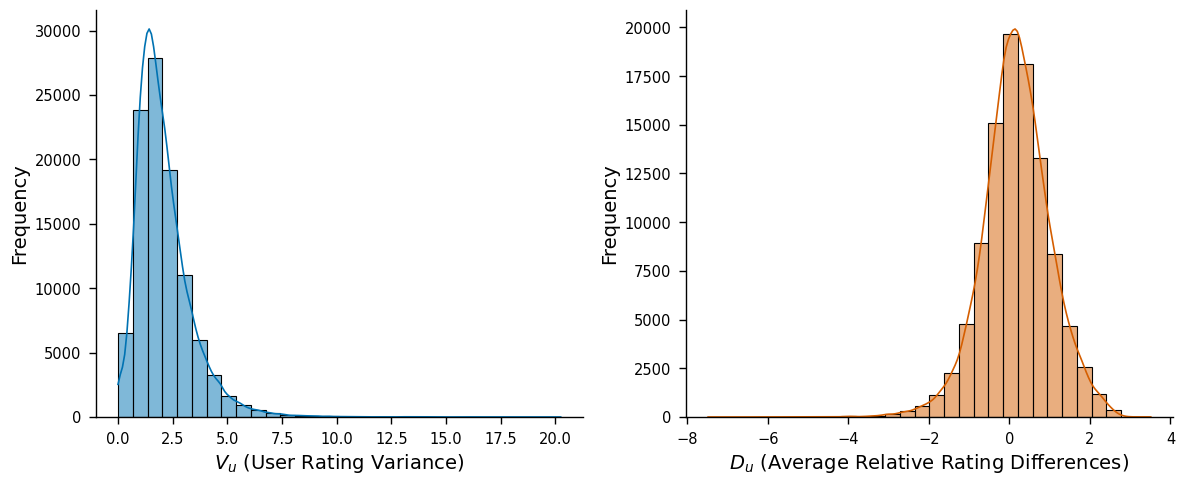

In [ ]:
#@title user analysis histograms

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load your dataset
df = final_user_stats

# Set the style for a scientific publication
plt.style.use('seaborn-v0_8-paper')
sns.set_context("paper", font_scale=1.2)

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: User Rating Variance (Vu)
# Color: #0072b2 (Blue from Okabe-Ito palette)
sns.histplot(df['personal_variance'], bins=30, kde=True, ax=axes[0], color='#0072b2')
axes[0].set_xlabel(r'$V_u$ (User Rating Variance)', fontsize=14)
axes[0].set_ylabel('Frequency', fontsize=14)

# Plot 2: Average Relative Difference (Du)
# Color: #d55e00 (Vermillion from Okabe-Ito palette)
sns.histplot(df['avg_score_diff'], bins=30, kde=True, ax=axes[1], color='#d55e00')
axes[1].set_xlabel(r'$D_u$ (Average Relative Rating Differences)', fontsize=14)
axes[1].set_ylabel('Frequency', fontsize=14)

# Remove borders
sns.despine()

# Adjust layout to prevent label truncation
plt.tight_layout()

# Save the figure for your manuscript
plt.savefig('figure_1_histograms.png', dpi=300)
plt.show()

In [ ]:
final_user_stats.shape

(101579, 3)

In [ ]:
final_user_stats.avg_score_diff.mean()

np.float64(0.17684715580316265)

In [ ]:
#@title comprehensive evaluation of number of clusters for kmeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.utils import resample
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
try:
    from kneed import KneeLocator
except ImportError:
    !pip install kneed
    from kneed import KneeLocator

from sklearn.preprocessing import StandardScaler

# 1. Prepare features
cluster_df = final_user_stats[['username', 'personal_variance', 'avg_score_diff']].dropna()
features = cluster_df[['personal_variance', 'avg_score_diff']]

# 2. Scale the data (this creates 'scaled_features' and 'scaler')
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

print(f"Scaled features created. Shape: {scaled_features.shape}")

def calculate_stability(k, data, iterations=5):
    ari_scores = []
    subset_size = min(20000, len(data))
    for i in range(iterations):
        s1 = resample(data, replace=True, n_samples=subset_size, random_state=i)
        s2 = resample(data, replace=True, n_samples=subset_size, random_state=i+100)
        m1 = KMeans(n_clusters=k, n_init='auto', random_state=42).fit(s1)
        m2 = KMeans(n_clusters=k, n_init='auto', random_state=42).fit(s2)
        labels1 = m1.predict(data[:subset_size])
        labels2 = m2.predict(data[:subset_size])
        ari_scores.append(adjusted_rand_score(labels1, labels2))
    return np.mean(ari_scores)

k_range = range(2, 11)
kmeans_eval_data = []

print("Calculating Metrics, Sizes, and Centroids for k=2 to 10...")

for k in k_range:
    km = KMeans(n_clusters=k, n_init='auto', random_state=42).fit(scaled_features)
    labels = km.labels_

    # Calculate Silhouette Score
    sil = silhouette_score(scaled_features, labels, sample_size=10000, random_state=42)

    # Get cluster sizes
    sizes = pd.Series(labels).value_counts().sort_index().tolist()

    # Get centroids (inverse transformed to original scale)
    centroids = scaler.inverse_transform(km.cluster_centers_)
    stability = calculate_stability(k, scaled_features)

    kmeans_eval_data.append({
        'k': k,
        'WCSS': km.inertia_,
        'Silhouette': sil,
        'Stability_ARI': stability,
        'cluster_sizes': sizes,
        'centroids_var_diff': centroids.tolist()
    })
    print(f"k={k} completed.")
    print(f"   Sizes: {sizes}")
    print(f"   Centroids: {centroids.tolist()}")

comparison_df = pd.DataFrame(kmeans_eval_data)

# Objective Knee Detection
kn_kmeans = KneeLocator(comparison_df['k'], comparison_df['WCSS'], curve='convex', direction='decreasing')
optimal_k_kmeans = kn_kmeans.knee

print(f"\nObjective KMeans Knee Detection: Optimal k = {optimal_k_kmeans}")
display(comparison_df)

Calculating Metrics, Sizes, and Centroids for k=2 to 10...
k=2 completed.
   Sizes: [67281, 34298]
   Centroids: [[1.4729295047394244, 0.5649887036024802], [3.313579560089768, -0.5904498652193376]]
k=3 completed.
   Sizes: [34123, 15578, 51878]
   Centroids: [[1.261100920762551, 1.0404103545320316], [4.29016997318093, -0.8138057148623415], [1.9823443590513254, -0.09790755852886382]]
k=4 completed.
   Sizes: [45532, 6220, 26330, 23497]
   Centroids: [[1.6349646307131958, 0.16555333045527287], [5.445045851005765, -0.9948604049492172], [2.915266633384689, -0.4952038486933521], [1.1737351315378362, 1.2557317952893436]]
k=5 completed.
   Sizes: [38509, 5267, 17907, 23098, 16798]
   Centroids: [[1.4810128676884042, 0.09766152409534463], [5.67010038369481, -0.9550837181513682], [2.986133298654164, 0.28622866922843726], [1.119341574858764, 1.2493776118597848], [2.762394491046496, -0.8877253071733066]]
k=6 completed.
   Sizes: [33053, 2746, 16043, 14677, 9972, 25088]
   Centroids: [[1.455382515

,k,WCSS,Silhouette,Stability_ARI,cluster_sizes,centroids_var_diff
0,2,115189.684735,0.420342,0.914057,"[67281, 34298]","[[1.4729295047394244, 0.5649887036024802], [3...."
1,3,81736.708424,0.368964,0.947448,"[34123, 15578, 51878]","[[1.261100920762551, 1.0404103545320316], [4.2..."
2,4,66876.123420,0.338198,0.779834,"[45532, 6220, 26330, 23497]","[[1.6349646307131958, 0.16555333045527287], [5..."
3,5,54892.154167,0.355490,0.838307,"[38509, 5267, 17907, 23098, 16798]","[[1.4810128676884042, 0.09766152409534463], [5..."
4,6,46544.229245,0.333964,0.699173,"[33053, 2746, 16043, 14677, 9972, 25088]","[[1.4553825151746085, 0.49002203937590627], [6..."
5,7,41268.404684,0.320511,0.677149,"[27796, 1799, 14765, 9921, 7028, 15368, 24902]","[[1.4877255082277232, 0.008845903234689645], [..."
6,8,36057.761081,0.334007,0.806378,"[24486, 1357, 7817, 8793, 21831, 4759, 16119, ...","[[1.384982409639497, -0.006516342702553607], [..."
7,9,32872.232888,0.320307,0.596481,"[20969, 995, 6262, 7048, 16230, 3690, 16363, 1...","[[1.2611812239197557, 0.3278175849122266], [8...."
8,10,29932.901693,0.322830,0.544053,"[22274, 679, 5891, 6634, 15787, 8221, 10709, 1...","[[1.3434469657534724, 0.256223040490109], [8.9..."


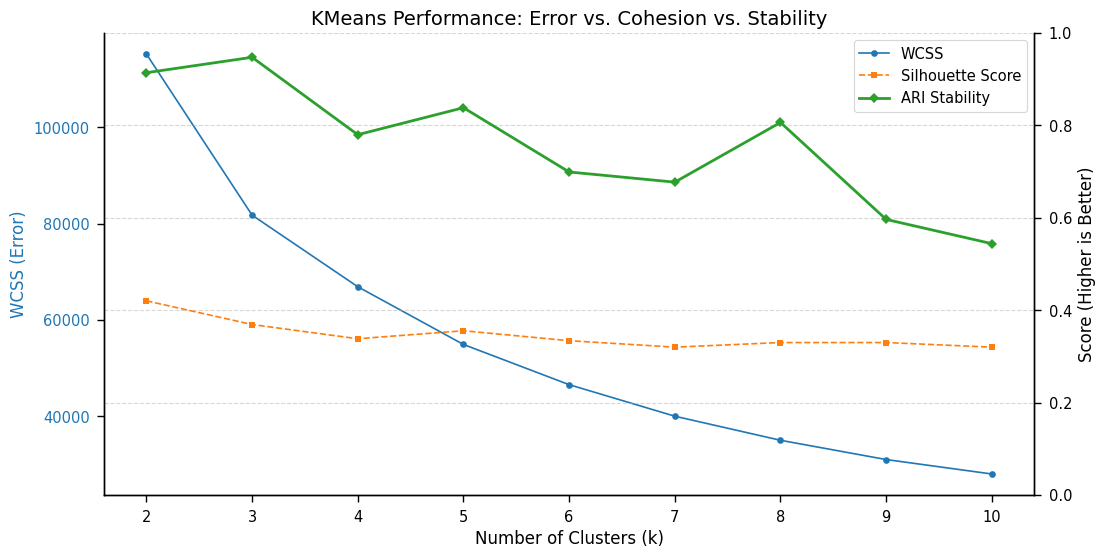


Decision Logic:
1. Look for the k where WCSS levels off (The Elbow).
2. Look for the k with the highest Stability (ARI).
3. Choose the k where Stability is high even if Silhouette drops slightly.


In [ ]:
#@title Combined Multi-Metric Cluster Selection Plot for kmeans
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax1 = plt.subplots(figsize=(12, 6))

# 1. Plot WCSS (Primary Y-axis)
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('WCSS (Error)', color=color, fontsize=12)
ax1.plot(comparison_df['k'], comparison_df['WCSS'], marker='o', color=color, label='WCSS')
ax1.tick_params(axis='y', labelcolor=color)

# 2. Plot Silhouette and Stability (Secondary Y-axis)
ax2 = ax1.twinx()
ax2.set_ylabel('Score (Higher is Better)', color='black', fontsize=12)
ax2.plot(comparison_df['k'], comparison_df['Silhouette'], marker='s', color='tab:orange', label='Silhouette Score', linestyle='--')
ax2.plot(comparison_df['k'], comparison_df['Stability_ARI'], marker='D', color='tab:green', label='ARI Stability', linewidth=2)
ax2.set_ylim(0, 1) # Metrics like Silhouette and ARI are bounded here

# Add legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

plt.title('KMeans Performance: Error vs. Cohesion vs. Stability', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
sns.despine(right=False)
plt.show()

print("\nDecision Logic:")
print("1. Look for the k where WCSS levels off (The Elbow).")
print("2. Look for the k with the highest Stability (ARI).")
print("3. Choose the k where Stability is high even if Silhouette drops slightly.")

In [ ]:
#@title comprehensive evaluation of number of clusters for GMM
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.utils import resample
import pandas as pd
import numpy as np
try:
    from kneed import KneeLocator
except ImportError:
    !pip install kneed
    from kneed import KneeLocator

def calculate_gmm_stability(k, data, iterations=5):
    ari_scores = []
    subset_size = min(20000, len(data))
    for i in range(iterations):
        s1 = resample(data, replace=True, n_samples=subset_size, random_state=i)
        s2 = resample(data, replace=True, n_samples=subset_size, random_state=i+100)
        m1 = GaussianMixture(n_components=k, n_init=1, random_state=42).fit(s1)
        m2 = GaussianMixture(n_components=k, n_init=1, random_state=42).fit(s2)
        labels1 = m1.predict(data[:subset_size])
        labels2 = m2.predict(data[:subset_size])
        ari_scores.append(adjusted_rand_score(labels1, labels2))
    return np.mean(ari_scores)

k_range = range(2, 11)
gmm_results = []

print("Calculating GMM Metrics, Sizes, and Means for k=2 to 10...")

for k in k_range:
    gmm = GaussianMixture(n_components=k, n_init=5, random_state=42).fit(scaled_features)
    labels = gmm.predict(scaled_features)
    bic = gmm.bic(scaled_features)
    stability = calculate_gmm_stability(k, scaled_features)

    # Calculate Silhouette Score
    sil = silhouette_score(scaled_features, labels, sample_size=10000, random_state=42)

    # Cluster sizes
    sizes = pd.Series(labels).value_counts().sort_index().tolist()

    # Cluster means (Centroids) - inverse transformed
    means = scaler.inverse_transform(gmm.means_)

    gmm_results.append({
        'k': k,
        'BIC': bic,
        'Silhouette': sil,
        'Stability_ARI': stability,
        'cluster_sizes': sizes,
        'means_var_diff': means.tolist()
    })
    print(f"k={k} completed.")
    print(f"   Sizes: {sizes}")
    print(f"   Means: {means.tolist()}")

gmm_comparison_df = pd.DataFrame(gmm_results)

# Objective Knee Detection for GMM (using BIC)
kn_gmm = KneeLocator(gmm_comparison_df['k'], gmm_comparison_df['BIC'], curve='convex', direction='decreasing')
optimal_k_gmm = kn_gmm.knee

print(f"\nObjective GMM Knee Detection: Optimal k = {optimal_k_gmm}")
display(gmm_comparison_df)

Calculating GMM Metrics, Sizes, and Means for k=2 to 10...
k=2 completed.
   Sizes: [82064, 19515]
   Means: [[1.6230651615484855, 0.3576090587002313], [3.355634688304039, -0.3113185113736002]]
k=3 completed.
   Sizes: [29618, 61669, 10292]
   Means: [[1.219988367360394, 0.7194814476766086], [2.1108369378899963, 0.061018458791452], [3.969123629627421, -0.6113904374096094]]
k=4 completed.
   Sizes: [54061, 15277, 28188, 4053]
   Means: [[1.5940858665547812, 0.1781074623764684], [1.1147643163826357, 1.1520850630465753], [2.9220683236372427, -0.2304988162581141], [4.827315022904832, -0.8957343126345702]]
k=5 completed.
   Sizes: [15517, 45684, 18957, 16556, 4865]
   Means: [[2.802816826673015, -0.6557835297971087], [1.4966237351469793, 0.14103880322253104], [1.2184437768421967, 1.123749154880864], [2.7594112615614725, 0.2829407008319197], [4.758469607006056, -0.9003395413558343]]
k=6 completed.
   Sizes: [35101, 11265, 11963, 26089, 15222, 1939]
   Means: [[1.4167007625165684, 0.452510146

,k,BIC,Silhouette,Stability_ARI,cluster_sizes,means_var_diff
0,2,508670.888612,0.437965,0.937317,"[82064, 19515]","[[1.6230651615484855, 0.3576090587002313], [3...."
1,3,501409.159666,0.313057,0.808149,"[29618, 61669, 10292]","[[1.219988367360394, 0.7194814476766086], [2.1..."
2,4,497824.758503,0.329897,0.799388,"[54061, 15277, 28188, 4053]","[[1.5940858665547812, 0.1781074623764684], [1...."
3,5,497787.246930,0.335814,0.826444,"[15517, 45684, 18957, 16556, 4865]","[[2.802816826673015, -0.6557835297971087], [1...."
4,6,496554.837362,0.322394,0.650152,"[35101, 11265, 11963, 26089, 15222, 1939]","[[1.4167007625165684, 0.4525101465561254], [3...."
5,7,495733.278930,0.331308,0.655613,"[14238, 24353, 14894, 8807, 6283, 31250, 1754]","[[1.0440532872646573, 1.2922276592316044], [2...."
6,8,495651.605613,0.323024,0.791481,"[4790, 27730, 7303, 14653, 1334, 7028, 21896, ...","[[3.9413482087444076, -1.2758591339910994], [1..."
7,9,495296.878060,0.311158,0.583874,"[14295, 11558, 25175, 1000, 4713, 6537, 19084,...","[[2.4233096000459904, 0.3368521815526315], [3...."
8,10,495003.820856,0.321569,0.523158,"[8865, 19643, 8947, 11887, 7406, 2370, 16230, ...","[[3.634147078460558, -0.16116004236156803], [1..."


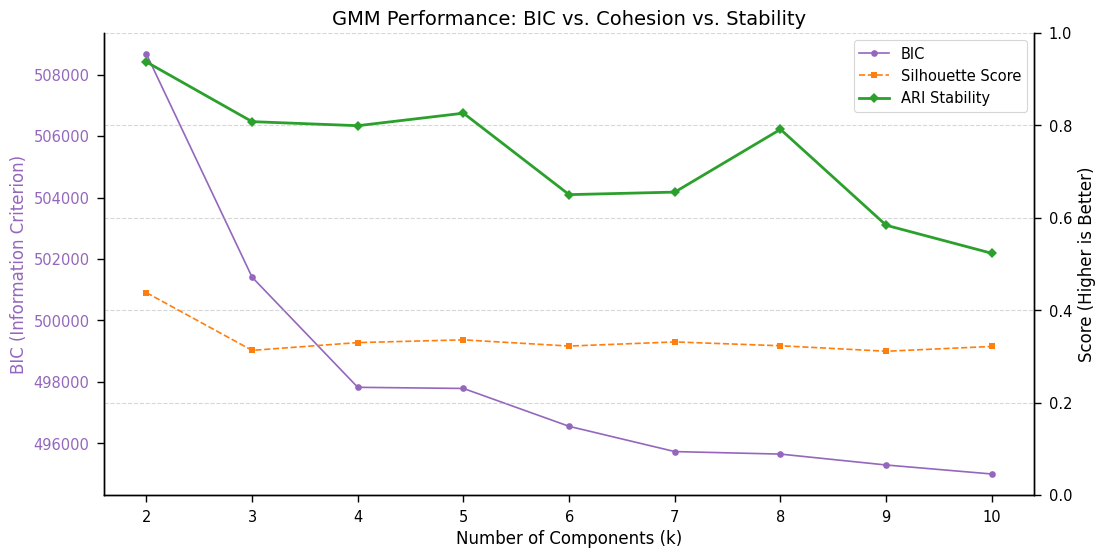


Decision Logic for GMM:
1. Identify the 'elbow' or minimum in the BIC curve.
2. Contrast stability against KMeans results; GMM often handles non-spherical data better but can be less stable.


In [ ]:
#@title Combined Multi-Metric Cluster Selection Plot for GMM
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax1 = plt.subplots(figsize=(12, 6))

# 1. Plot BIC (Primary Y-axis) - Note: Lower BIC is generally better
color = 'tab:purple'
ax1.set_xlabel('Number of Components (k)', fontsize=12)
ax1.set_ylabel('BIC (Information Criterion)', color=color, fontsize=12)
ax1.plot(gmm_comparison_df['k'], gmm_comparison_df['BIC'], marker='o', color=color, label='BIC')
ax1.tick_params(axis='y', labelcolor=color)

# 2. Plot Silhouette and Stability (Secondary Y-axis)
ax2 = ax1.twinx()
ax2.set_ylabel('Score (Higher is Better)', color='black', fontsize=12)
ax2.plot(gmm_comparison_df['k'], gmm_comparison_df['Silhouette'], marker='s', color='tab:orange', label='Silhouette Score', linestyle='--')
ax2.plot(gmm_comparison_df['k'], gmm_comparison_df['Stability_ARI'], marker='D', color='tab:green', label='ARI Stability', linewidth=2)
ax2.set_ylim(0, 1)

# Add legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

plt.title('GMM Performance: BIC vs. Cohesion vs. Stability', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
sns.despine(right=False)
plt.show()

print("\nDecision Logic for GMM:")
print("1. Identify the 'elbow' or minimum in the BIC curve.")
print("2. Contrast stability against KMeans results; GMM often handles non-spherical data better but can be less stable.")

In [ ]:
#@title prepare data for training by populating user features for kmeans

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("1. Preparing and scaling the data...")
# Isolate the features and drop any missing values
cluster_df = final_user_stats[['username', 'personal_variance', 'avg_score_diff']].dropna()
features = cluster_df[['personal_variance', 'avg_score_diff']]

# Scale the data (crucial for K-Means distance calculations)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

print("2. Running K-Means (k=3)...")
# Fit the model and get the raw cluster labels (0, 1, or 2)
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
cluster_df['cluster_num'] = kmeans.fit_predict(scaled_features)

print("3. Extracting Centroids to classify groups...")
# Extract the exact mathematical center (centroid) of each cluster
# We use inverse_transform to convert them from Z-scores back to normal numbers
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

# Create a mini dataframe just for the centroids to make them easy to sort
centroids_df = pd.DataFrame(centroids, columns=['centroid_variance', 'centroid_score_diff'])
centroids_df['cluster_num'] = centroids_df.index # Index 0, 1, 2 matches the cluster labels

# Sort the centroids from lowest score difference to highest
centroids_sorted = centroids_df.sort_values(by='centroid_score_diff')

# 4. Map the sorted centroids to our human labels
# iloc[0] is the lowest score diff, iloc[2] is the highest
label_mapping = {
    centroids_sorted.iloc[0]['cluster_num']: 'Critical',
    centroids_sorted.iloc[1]['cluster_num']: 'Average',
    centroids_sorted.iloc[2]['cluster_num']: 'Generous'
}

print(f"Centroid Mapping Logic: \n{label_mapping}\n")

# Apply the mapped labels back to our users
cluster_df['user_persona'] = cluster_df['cluster_num'].map(label_mapping)

print("4. Merging with full user profile data...")
# Load the original users dataset
# (Ensure base_path is defined, e.g., base_path = '/content/drive/MyDrive/kaden_projects/')
users_full = pd.read_csv(base_path + 'users_cleaned.csv')

# Inner merge to combine the persona classifications with the demographic data
classified_users_df = users_full.merge(
    cluster_df[['username', 'user_persona', 'personal_variance', 'avg_score_diff']],
    on='username',
    how='inner'
)

print("\n--- Final Classified DataFrame ---")
display(classified_users_df.head(10))

1. Preparing and scaling the data...
2. Running K-Means (k=3)...
3. Extracting Centroids to classify groups...
Centroid Mapping Logic: 
{np.float64(1.0): 'Critical', np.float64(2.0): 'Average', np.float64(0.0): 'Generous'}

4. Merging with full user profile data...

--- Final Classified DataFrame ---


,username,user_id,user_watching,user_completed,user_onhold,user_dropped,user_plantowatch,user_days_spent_watching,gender,location,birth_date,access_rank,join_date,last_online,stats_mean_score,stats_rewatched,stats_episodes,user_persona,personal_variance,avg_score_diff
0,karthiga,2255153,3,49,1,0,0,55.091667,Female,"Chennai, India",1990-04-29 00:00:00,NaN,2013-03-03 00:00:00,2014-02-04 01:32:00,7.43,0.0,3391,Average,1.490922,-0.509057
1,Damonashu,37326,45,195,27,25,59,82.574306,Male,"Detroit,Michigan",1991-08-01 00:00:00,NaN,2008-02-13 00:00:00,2017-07-10 06:52:54,6.15,6.0,4903,Critical,4.212988,-1.578196
2,bskai,228342,25,414,2,5,11,159.483333,Male,"Nayarit, Mexico",1990-12-14 00:00:00,NaN,2009-08-31 00:00:00,2014-05-12 16:35:00,8.27,1.0,9701,Generous,1.527116,0.954353
3,terune_uzumaki,327311,5,5,0,0,0,11.394444,Female,"Malaysia, Kuantan",1998-08-24 00:00:00,NaN,2010-05-10 00:00:00,2012-10-18 19:06:00,9.70,6.0,697,Generous,0.210000,1.985000
4,Bas_G,5015094,35,114,6,20,175,30.458333,Male,"Nijmegen, Nederland",1999-10-24 00:00:00,NaN,2015-11-26 00:00:00,2018-05-10 20:53:37,7.86,0.0,1847,Average,1.305349,0.123186
5,HimeAria,3129315,2,87,2,0,28,19.963194,Female,Poland,1996-09-26 00:00:00,NaN,2013-09-08 00:00:00,2018-01-14 13:05:42,8.23,0.0,1314,Generous,1.329365,0.531310
6,Slimak,61677,79,224,0,3,84,124.731944,Male,Poland,1988-02-21 00:00:00,NaN,2008-05-18 00:00:00,2018-05-01 12:05:21,7.77,2.0,7447,Average,1.243661,0.193722
7,jimothy000,47167,6,0,0,0,2,2.040972,Male,"England,Manchester",1995-04-25 00:00:00,NaN,2008-04-01 00:00:00,2008-04-27 16:00:00,9.33,5.0,126,Generous,0.222222,1.355000
8,MistButterfly,2485327,66,3923,115,0,368,608.234514,Female,~ Hungary ~,1992-01-16 00:00:00,NaN,2013-04-25 00:00:00,2018-05-17 13:31:00,5.49,0.0,39703,Average,2.000136,-1.471106
9,ProperBritish,253613,6,233,7,9,62,43.728472,Male,United Kingdom,1992-02-20 00:00:00,NaN,2009-11-01 00:00:00,2018-04-16 20:37:18,8.00,2.0,2625,Average,1.943746,0.386180


In [ ]:
cluster_df

,username,personal_variance,avg_score_diff,cluster_num,user_persona
0,-Kenjiro,2.005706,-0.500741,2,Average
1,Acidblood,1.496078,-0.362933,2,Average
2,Ahmad317,2.610303,-0.322156,2,Average
3,AkaMaster,0.830181,0.284058,0,Generous
4,Akasaka24,4.114733,-1.326025,1,Critical
...,...,...,...,...,...
101574,zfkl,1.141274,0.986053,0,Generous
101575,zhorahh,1.052632,0.146842,2,Average
101576,zimo,3.162630,0.832353,2,Average
101577,ziroDay,1.861797,1.296852,0,Generous


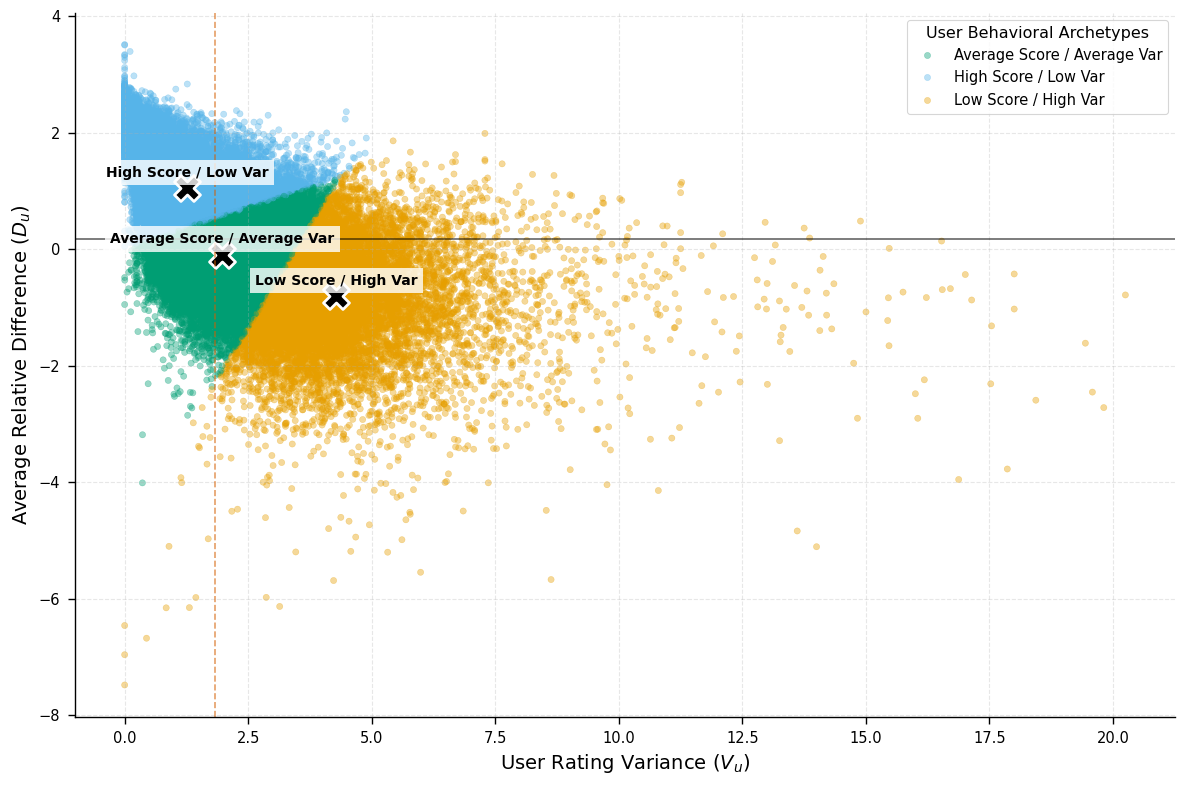

Cluster Distribution Summary (User Counts):
- Average Score / Average Var: 51,878 users
- High Score / Low Var: 34,123 users
- Low Score / High Var: 15,578 users


In [ ]:
#@title visualize kmeans clusters (Specific Technical Names)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Map specific names requested by user based on centroid characteristics
# Cluster 0: Low variance, High avg_score_diff -> High Score / Low Var
# Cluster 1: High variance -> Low Score / High Var
# Cluster 2: Mid variance, Low/Mid diff -> Average Score / Average Var

cluster_to_name = {
    0: "High Score / Low Var",
    1: "Low Score / High Var",
    2: "Average Score / Average Var"
}

# Map the names to our dataframe
cluster_df['cluster_name'] = cluster_df['cluster_num'].map(cluster_to_name)

# 2. Get the Centroids for plotting
centroids_plot = cluster_df.groupby('cluster_num').agg({
    'personal_variance': 'mean',
    'avg_score_diff': 'mean'
}).reset_index()

# --- VISUALIZATION ---
plt.figure(figsize=(12, 8))
palette = {
    "High Score / Low Var": "#56B4E9",
    "Low Score / High Var": "#E69F00",
    "Average Score / Average Var": "#009E73"
}

sns.scatterplot(
    data=cluster_df,
    x='personal_variance', y='avg_score_diff',
    hue='cluster_name', palette=palette,
    alpha=0.4, s=20, edgecolor=None
)

# Plot Centroids with labels
for _, row in centroids_plot.iterrows():
    cluster_id = int(row['cluster_num'])
    name = cluster_to_name.get(cluster_id)
    plt.scatter(row['personal_variance'], row['avg_score_diff'],
                marker='X', s=350, color='black', edgecolor='white', linewidth=2)
    plt.text(row['personal_variance'], row['avg_score_diff'] + 0.2,
             name, weight='bold', size=10, ha='center',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Add Quadrant Lines
plt.axvline(x=cluster_df['personal_variance'].median(), color='#D55E00', linestyle='--', alpha=0.6)
plt.axhline(y=cluster_df['avg_score_diff'].mean(), color='black', linestyle='-', alpha=0.6)

# Format labels (using LaTeX for mathematical notation)
plt.xlabel('User Rating Variance ($V_u$)', fontsize=14)
plt.ylabel('Average Relative Difference ($D_u$)', fontsize=14)
plt.legend(loc='upper right', title="User Behavioral Archetypes")
plt.grid(True, linestyle='--', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

# Report Total Users per Cluster
print("Cluster Distribution Summary (User Counts):")
distribution = cluster_df['cluster_name'].value_counts().sort_index()
for name, count in distribution.items():
    print(f"- {name}: {count:,} users")

In [ ]:
list_df = classified_users_df.drop(columns=['username', 'user_id', 'access_rank', 'stats_mean_score', 'personal_variance', 'avg_score_diff'])
display(list_df.head(10))

,user_watching,user_completed,user_onhold,user_dropped,user_plantowatch,user_days_spent_watching,gender,location,birth_date,join_date,last_online,stats_rewatched,stats_episodes,user_persona
0,3,49,1,0,0,55.091667,Female,"Chennai, India",1990-04-29 00:00:00,2013-03-03 00:00:00,2014-02-04 01:32:00,0.0,3391,Average
1,45,195,27,25,59,82.574306,Male,"Detroit,Michigan",1991-08-01 00:00:00,2008-02-13 00:00:00,2017-07-10 06:52:54,6.0,4903,Critical
2,25,414,2,5,11,159.483333,Male,"Nayarit, Mexico",1990-12-14 00:00:00,2009-08-31 00:00:00,2014-05-12 16:35:00,1.0,9701,Generous
3,5,5,0,0,0,11.394444,Female,"Malaysia, Kuantan",1998-08-24 00:00:00,2010-05-10 00:00:00,2012-10-18 19:06:00,6.0,697,Generous
4,35,114,6,20,175,30.458333,Male,"Nijmegen, Nederland",1999-10-24 00:00:00,2015-11-26 00:00:00,2018-05-10 20:53:37,0.0,1847,Average
5,2,87,2,0,28,19.963194,Female,Poland,1996-09-26 00:00:00,2013-09-08 00:00:00,2018-01-14 13:05:42,0.0,1314,Generous
6,79,224,0,3,84,124.731944,Male,Poland,1988-02-21 00:00:00,2008-05-18 00:00:00,2018-05-01 12:05:21,2.0,7447,Average
7,6,0,0,0,2,2.040972,Male,"England,Manchester",1995-04-25 00:00:00,2008-04-01 00:00:00,2008-04-27 16:00:00,5.0,126,Generous
8,66,3923,115,0,368,608.234514,Female,~ Hungary ~,1992-01-16 00:00:00,2013-04-25 00:00:00,2018-05-17 13:31:00,0.0,39703,Average
9,6,233,7,9,62,43.728472,Male,United Kingdom,1992-02-20 00:00:00,2009-11-01 00:00:00,2018-04-16 20:37:18,2.0,2625,Average


In [ ]:
list_df.location.unique().shape

(37979,)

In [ ]:

display(list_df.head(10))

,user_watching,user_completed,user_onhold,user_dropped,user_plantowatch,user_days_spent_watching,gender,location,birth_date,join_date,last_online,stats_rewatched,stats_episodes,user_persona
0,3,49,1,0,0,55.091667,Female,"Chennai, India",1990-04-29 00:00:00,2013-03-03 00:00:00,2014-02-04 01:32:00,0.0,3391,Average
1,45,195,27,25,59,82.574306,Male,"Detroit,Michigan",1991-08-01 00:00:00,2008-02-13 00:00:00,2017-07-10 06:52:54,6.0,4903,Critical
2,25,414,2,5,11,159.483333,Male,"Nayarit, Mexico",1990-12-14 00:00:00,2009-08-31 00:00:00,2014-05-12 16:35:00,1.0,9701,Generous
3,5,5,0,0,0,11.394444,Female,"Malaysia, Kuantan",1998-08-24 00:00:00,2010-05-10 00:00:00,2012-10-18 19:06:00,6.0,697,Generous
4,35,114,6,20,175,30.458333,Male,"Nijmegen, Nederland",1999-10-24 00:00:00,2015-11-26 00:00:00,2018-05-10 20:53:37,0.0,1847,Average
5,2,87,2,0,28,19.963194,Female,Poland,1996-09-26 00:00:00,2013-09-08 00:00:00,2018-01-14 13:05:42,0.0,1314,Generous
6,79,224,0,3,84,124.731944,Male,Poland,1988-02-21 00:00:00,2008-05-18 00:00:00,2018-05-01 12:05:21,2.0,7447,Average
7,6,0,0,0,2,2.040972,Male,"England,Manchester",1995-04-25 00:00:00,2008-04-01 00:00:00,2008-04-27 16:00:00,5.0,126,Generous
8,66,3923,115,0,368,608.234514,Female,~ Hungary ~,1992-01-16 00:00:00,2013-04-25 00:00:00,2018-05-17 13:31:00,0.0,39703,Average
9,6,233,7,9,62,43.728472,Male,United Kingdom,1992-02-20 00:00:00,2009-11-01 00:00:00,2018-04-16 20:37:18,2.0,2625,Average


In [ ]:
#@title classification using decision tree: no leakage
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, f1_score, classification_report, balanced_accuracy_score
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.dummy import DummyClassifier
from scipy import stats

# --- Constants ---
TARGET_DATE = pd.to_datetime('2026-01-01')
COLS_TO_DROP = ['username', 'user_id', 'access_rank', 'stats_mean_score', 'personal_variance', 'avg_score_diff', 'location']
DATE_COLS = ['birth_date', 'join_date', 'last_online']
EQUIVALENCE_MARGIN = 0.02

def corrected_resampled_t_test(diffs, n_train, n_test):
    n = len(diffs)
    mean_diff = np.mean(diffs)
    var_diff = np.var(diffs, ddof=1)
    # The correction term (1/n + n_test/n_train) handles the lack of independence in CV folds
    corrected_var = var_diff * (1/n + n_test/n_train)
    t_stat = mean_diff / np.sqrt(max(corrected_var, 1e-9))
    p_val = (1 - stats.t.cdf(abs(t_stat), n - 1)) * 2
    return t_stat, p_val

def tost_equivalence(diffs, margin, n_train, n_test):
    n = len(diffs)
    mean_diff = np.mean(diffs)
    var_diff = np.var(diffs, ddof=1)
    corrected_var = var_diff * (1/n + n_test/n_train)
    se = np.sqrt(max(corrected_var, 1e-9))
    t1 = (mean_diff - (-margin)) / se
    t2 = (mean_diff - margin) / se
    p1 = 1 - stats.t.cdf(t1, n - 1)
    p2 = stats.t.cdf(t2, n - 1)
    return max(p1, p2)

# Setup data
users_full = pd.read_csv(base_path + 'users_cleaned.csv')
common_usernames = pd.merge(users_full[['username']], final_user_stats[['username']], on='username')['username'].unique()
users_full_f = users_full[users_full['username'].isin(common_usernames)].reset_index(drop=True)
stats_f = final_user_stats[final_user_stats['username'].isin(common_usernames)].reset_index(drop=True)

kf = KFold(n_splits=10, shuffle=True, random_state=42)
scenarios = [
    {'name': 'KMeans (k=3)', 'model': KMeans(n_clusters=3, random_state=42, n_init='auto'), 'labels': ['Critical', 'Engaged', 'Transient']},
    {'name': 'GMM (k=4)', 'model': GaussianMixture(n_components=4, random_state=42, n_init=1), 'labels': ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']}
]

for scenario in scenarios:
    print(f"\n{'='*80}\nSCENARIO: {scenario['name']}\n{'='*80}")
    results = {m: {'bal_acc': [], 'f1': []} for m in ['DT', 'Majority', 'Stratified']}
    oof_preds = {m: [] for m in ['DT', 'Majority', 'Stratified', 'True']}

    for train_idx, test_idx in kf.split(common_usernames):
        train_u, test_u = common_usernames[train_idx], common_usernames[test_idx]
        train_c = stats_f[stats_f['username'].isin(train_u)].copy()
        scaler_c = StandardScaler().fit(train_c[['personal_variance', 'avg_score_diff']])
        scenario['model'].fit(scaler_c.transform(train_c[['personal_variance', 'avg_score_diff']]))

        means = scenario['model'].cluster_centers_ if scenario['name'].startswith('KMeans') else scenario['model'].means_
        inv_c = scaler_c.inverse_transform(means)
        sorted_idx = np.argsort(inv_c[:, 1])
        mapping = {idx: scenario['labels'][i] for i, idx in enumerate(sorted_idx)}

        train_d, test_d = users_full_f[users_full_f['username'].isin(train_u)].copy(), users_full_f[users_full_f['username'].isin(test_u)].copy()
        def engineer(df):
            for c in DATE_COLS: df[c] = pd.to_datetime(df[c], errors='coerce')
            df['months_since_join'] = (TARGET_DATE.year - df['join_date'].dt.year)*12 + (TARGET_DATE.month - df['join_date'].dt.month)
            df['active_duration_months'] = (df['last_online'].dt.year - df['join_date'].dt.year)*12 + (df['last_online'].dt.month - df['join_date'].dt.month)
            res = df.drop(columns=DATE_COLS + COLS_TO_DROP, errors='ignore')
            return res.fillna(res.median(numeric_only=True))

        X_train, X_test = engineer(train_d), engineer(test_d)
        # Predict personas for all based on global clustering map
        y_map = pd.Series([mapping[l] for l in scenario['model'].predict(scaler_c.transform(stats_f[['personal_variance', 'avg_score_diff']]))], index=stats_f['username'])
        y_train, y_test = y_map.loc[train_u], y_map.loc[test_u]

        pre = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), X_train.select_dtypes(include=['object']).columns.tolist())], remainder='passthrough')
        for m_name, m_obj in [('DT', DecisionTreeClassifier(max_depth=12, class_weight='balanced', random_state=42)), ('Majority', DummyClassifier(strategy='most_frequent')), ('Stratified', DummyClassifier(strategy='stratified', random_state=42))]:
            pipe = Pipeline([('pre', pre), ('clf', m_obj)]).fit(X_train, y_train)
            p = pipe.predict(X_test)
            results[m_name]['bal_acc'].append(balanced_accuracy_score(y_test, p))
            results[m_name]['f1'].append(f1_score(y_test, p, average='macro'))
            oof_preds[m_name].extend(p)
        oof_preds['True'].extend(y_test)

    n_train, n_test = len(train_u), len(test_u)
    for model in ['DT', 'Majority', 'Stratified']:
        print(f"\nREPORT FOR {model} ({scenario['name']})")
        print("-"*60)
        print(f"Balanced Accuracy: {np.mean(results[model]['bal_acc']):.4f} \u00b1 {np.std(results[model]['bal_acc']):.4f}")
        print(f"Macro F1 Score:     {np.mean(results[model]['f1']):.4f} \u00b1 {np.std(results[model]['f1']):.4f}")

        if model != 'DT':
            for metric_key, metric_name in [('bal_acc', 'Balanced Accuracy'), ('f1', 'Macro F1')]:
                diffs = np.array(results['DT'][metric_key]) - np.array(results[model][metric_key])
                t_stat, p_val = corrected_resampled_t_test(diffs, n_train, n_test)
                tost_p = tost_equivalence(diffs, EQUIVALENCE_MARGIN, n_train, n_test)
                print(f"Corrected t-test ({metric_name}) [DT vs {model}]: p={p_val:.6f}")
                print(f"TOST Equivalence ({metric_name}) [margin {EQUIVALENCE_MARGIN}]: p={tost_p:.4f} ({'Equivalent' if tost_p < 0.05 else 'Not Equivalent'})")

        print(f"\nClassification Report for {model}:")
        print(classification_report(oof_preds['True'], oof_preds[model], target_names=scenario['labels']))


SCENARIO: KMeans (k=3)

REPORT FOR DT (KMeans (k=3))
------------------------------------------------------------
Balanced Accuracy: 0.4814 ± 0.0029
Macro F1 Score:     0.4426 ± 0.0061

Classification Report for DT:
              precision    recall  f1-score   support

    Critical       0.26      0.51      0.34     15933
     Engaged       0.58      0.36      0.45     52035
   Transient       0.50      0.58      0.54     33611

    accuracy                           0.46    101579
   macro avg       0.45      0.48      0.44    101579
weighted avg       0.51      0.46      0.46    101579


REPORT FOR Majority (KMeans (k=3))
------------------------------------------------------------
Balanced Accuracy: 0.3333 ± 0.0000
Macro F1 Score:     0.2258 ± 0.0020
Corrected t-test (Balanced Accuracy) [DT vs Majority]: p=0.000000
TOST Equivalence (Balanced Accuracy) [margin 0.02]: p=1.0000 (Not Equivalent)
Corrected t-test (Macro F1) [DT vs Majority]: p=0.000000
TOST Equivalence (Macro F1) [marg

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

    Critical       0.00      0.00      0.00     15933
     Engaged       0.51      1.00      0.68     52035
   Transient       0.00      0.00      0.00     33611

    accuracy                           0.51    101579
   macro avg       0.17      0.33      0.23    101579
weighted avg       0.26      0.51      0.35    101579


REPORT FOR Stratified (KMeans (k=3))
------------------------------------------------------------
Balanced Accuracy: 0.3322 ± 0.0055
Macro F1 Score:     0.3322 ± 0.0055
Corrected t-test (Balanced Accuracy) [DT vs Stratified]: p=0.000000
TOST Equivalence (Balanced Accuracy) [margin 0.02]: p=1.0000 (Not Equivalent)
Corrected t-test (Macro F1) [DT vs Stratified]: p=0.000000
TOST Equivalence (Macro F1) [margin 0.02]: p=1.0000 (Not Equivalent)

Classification Report for Stratified:
              precision    recall  f1-score   support

    Critical       0.16      0.15      0.15     15933
     Engaged       0.51    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

   Cluster 1       0.00      0.00      0.00      4291
   Cluster 2       0.00      0.00      0.00     28626
   Cluster 3       0.53      1.00      0.69     53582
   Cluster 4       0.00      0.00      0.00     15080

    accuracy                           0.53    101579
   macro avg       0.13      0.25      0.17    101579
weighted avg       0.28      0.53      0.36    101579


REPORT FOR Stratified (GMM (k=4))
------------------------------------------------------------
Balanced Accuracy: 0.2508 ± 0.0024
Macro F1 Score:     0.2508 ± 0.0023
Corrected t-test (Balanced Accuracy) [DT vs Stratified]: p=0.000000
TOST Equivalence (Balanced Accuracy) [margin 0.02]: p=1.0000 (Not Equivalent)
Corrected t-test (Macro F1) [DT vs Stratified]: p=0.000000
TOST Equivalence (Macro F1) [margin 0.02]: p=1.0000 (Not Equivalent)

Classification Report for Stratified:
              precision    recall  f1-score   support

   Cluster 1       0.04      0


SCENARIO: KMeans (k=3) (Random Forest)
Balanced Accuracy: 0.5111 ± 0.0049
Macro F1 Score:     0.4767 ± 0.0032

Classification Report:
              precision    recall  f1-score   support

    Critical       0.31      0.51      0.38     15933
     Engaged       0.60      0.40      0.48     52035
   Transient       0.52      0.62      0.56     33611

    accuracy                           0.49    101579
   macro avg       0.48      0.51      0.48    101579
weighted avg       0.53      0.49      0.49    101579


OOS Confusion Matrix (Raw Counts):


,Pred Critical,Pred Engaged,Pred Transient
True Critical,8176,4988,2769
True Engaged,14611,21062,16362
True Transient,3985,8941,20685



OOS Confusion Matrix (Normalized Recall %):


,Recall Critical,Recall Engaged,Recall Transient
True Critical,51.31%,31.31%,17.38%
True Engaged,28.08%,40.48%,31.44%
True Transient,11.86%,26.60%,61.54%


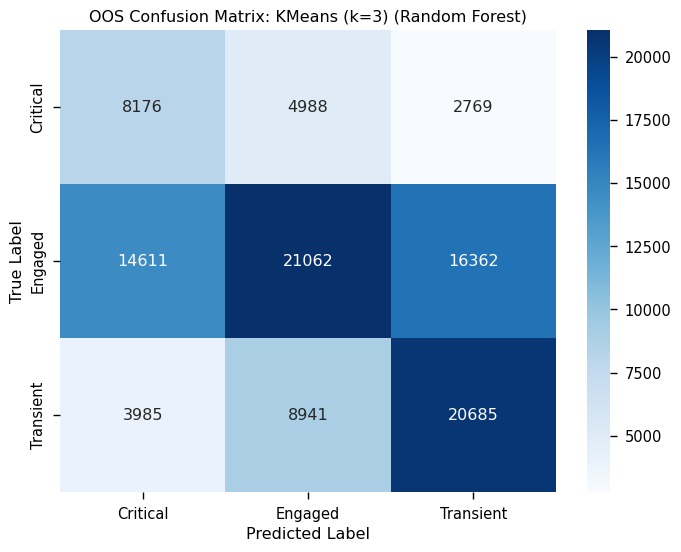


SCENARIO: GMM (k=4) (Random Forest)
Balanced Accuracy: 0.4109 ± 0.0077
Macro F1 Score:     0.3608 ± 0.0060

Classification Report:
              precision    recall  f1-score   support

   Cluster 1       0.13      0.22      0.17      4291
   Cluster 2       0.39      0.51      0.44     28626
   Cluster 3       0.62      0.33      0.43     53582
   Cluster 4       0.31      0.58      0.40     15080

    accuracy                           0.41    101579
   macro avg       0.36      0.41      0.36    101579
weighted avg       0.49      0.41      0.42    101579


OOS Confusion Matrix (Raw Counts):


,Pred Cluster 1,Pred Cluster 2,Pred Cluster 3,Pred Cluster 4
True Cluster 1,952,2047,747,545
True Cluster 2,3177,14555,6611,4283
True Cluster 3,2610,18181,17794,14997
True Cluster 4,333,2317,3669,8761



OOS Confusion Matrix (Normalized Recall %):


,Recall Cluster 1,Recall Cluster 2,Recall Cluster 3,Recall Cluster 4
True Cluster 1,22.19%,47.70%,17.41%,12.70%
True Cluster 2,11.10%,50.85%,23.09%,14.96%
True Cluster 3,4.87%,33.93%,33.21%,27.99%
True Cluster 4,2.21%,15.36%,24.33%,58.10%


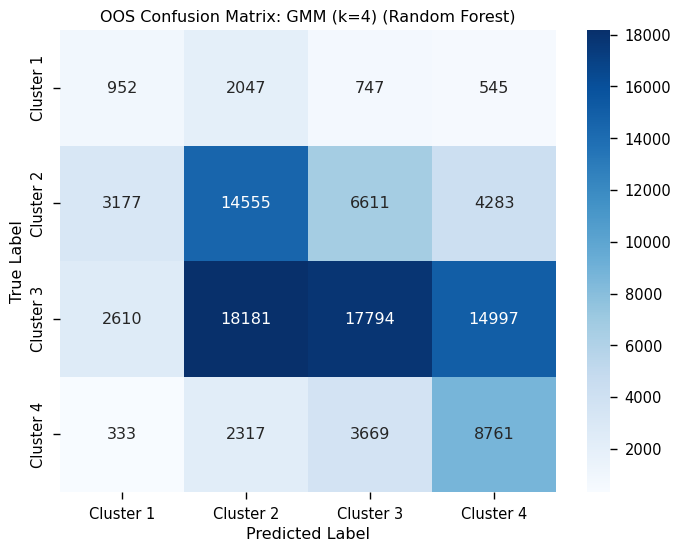

In [ ]:
#@title classification using random forest: no leakage
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, balanced_accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

results_rf_no_leakage = {scenario['name']: {'bal_acc': [], 'f1': []} for scenario in scenarios}

for scenario in scenarios:
    print(f"\n{'='*80}\nSCENARIO: {scenario['name']} (Random Forest)\n{'='*80}")
    oof_preds_rf = []
    oof_true = []

    for train_idx, test_idx in kf.split(common_usernames):
        train_u, test_u = common_usernames[train_idx], common_usernames[test_idx]
        train_c = stats_f[stats_f['username'].isin(train_u)].copy()
        scaler_c = StandardScaler().fit(train_c[['personal_variance', 'avg_score_diff']])
        scenario['model'].fit(scaler_c.transform(train_c[['personal_variance', 'avg_score_diff']]))

        means = scenario['model'].cluster_centers_ if scenario['name'].startswith('KMeans') else scenario['model'].means_
        inv_c = scaler_c.inverse_transform(means)
        mapping = {idx: scenario['labels'][i] for i, idx in enumerate(np.argsort(inv_c[:, 1]))}

        train_d, test_d = users_full_f[users_full_f['username'].isin(train_u)].copy(), users_full_f[users_full_f['username'].isin(test_u)].copy()
        X_train, X_test = engineer_features(train_d), engineer_features(test_d)

        y_map = pd.Series([mapping[l] for l in scenario['model'].predict(scaler_c.transform(stats_f[['personal_variance', 'avg_score_diff']]))], index=stats_f['username'])
        y_train, y_test = y_map.loc[train_u], y_map.loc[test_u]

        cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
        pre = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)], remainder='passthrough')

        rf_model = RandomForestClassifier(n_estimators=200, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1)
        pipe = Pipeline([('pre', pre), ('clf', rf_model)]).fit(X_train, y_train)

        p = pipe.predict(X_test)
        results_rf_no_leakage[scenario['name']]['bal_acc'].append(balanced_accuracy_score(y_test, p))
        results_rf_no_leakage[scenario['name']]['f1'].append(f1_score(y_test, p, average='macro'))
        oof_preds_rf.extend(p)
        oof_true.extend(y_test)

    # Display Performance Metrics
    print(f"Balanced Accuracy: {np.mean(results_rf_no_leakage[scenario['name']]['bal_acc']):.4f} \u00b1 {np.std(results_rf_no_leakage[scenario['name']]['bal_acc']):.4f}")
    print(f"Macro F1 Score:     {np.mean(results_rf_no_leakage[scenario['name']]['f1']):.4f} \u00b1 {np.std(results_rf_no_leakage[scenario['name']]['f1']):.4f}")
    print("\nClassification Report:")
    print(classification_report(oof_true, oof_preds_rf, target_names=scenario['labels']))

    # Calculate Confusion Matrix
    cm = confusion_matrix(oof_true, oof_preds_rf, labels=scenario['labels'])

    # Textual Matrix: Raw Counts
    cm_raw_df = pd.DataFrame(cm, index=[f'True {l}' for l in scenario['labels']], columns=[f'Pred {l}' for l in scenario['labels']])
    print("\nOOS Confusion Matrix (Raw Counts):")
    display(cm_raw_df)

    # Textual Matrix: Normalized Recall (Percentage per Class)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_norm_df = pd.DataFrame(cm_norm, index=[f'True {l}' for l in scenario['labels']], columns=[f'Recall {l}' for l in scenario['labels']])
    print("\nOOS Confusion Matrix (Normalized Recall %):")
    display(cm_norm_df.style.format("{:.2%}"))

    # Visual Heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=scenario['labels'], yticklabels=scenario['labels'])
    plt.title(f"OOS Confusion Matrix: {scenario['name']} (Random Forest)")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()


SCENARIO: KMeans (k=3) (LightGBM)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Balanced Accuracy: 0.5158 ± 0.0040
Macro F1 Score:     0.4667 ± 0.0032

Classification Report:
              precision    recall  f1-score   support

    Critical       0.29      0.57      0.39     15933
     Engaged       0.61      0.35      0.45     52035
   Transient       0.52      0.62      0.57     33611

    accuracy                           0.48    101579
   macro avg       0.47      0.52      0.47    101579
weighted avg       0.53      0.48      0.48    101579


OOS Confusion Matrix (Raw Counts):


,Pred Critical,Pred Engaged,Pred Transient
True Critical,9087,4070,2776
True Engaged,16976,18350,16709
True Transient,5042,7580,20989



OOS Confusion Matrix (Normalized Recall %):


,Recall Critical,Recall Engaged,Recall Transient
True Critical,57.03%,25.54%,17.42%
True Engaged,32.62%,35.26%,32.11%
True Transient,15.00%,22.55%,62.45%


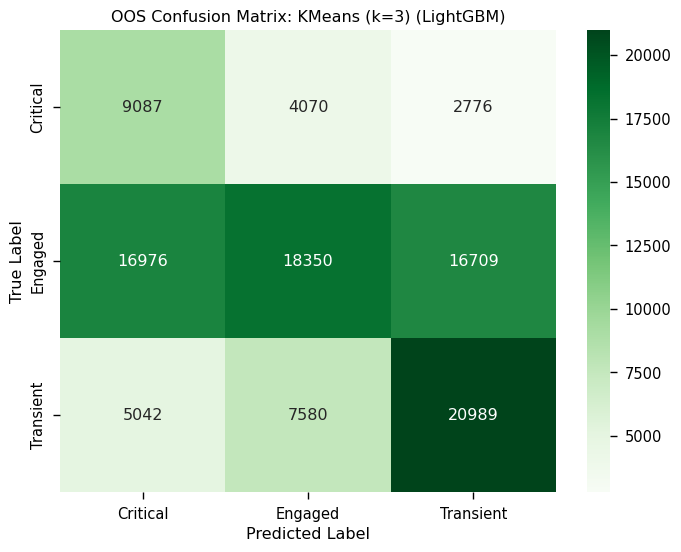


SCENARIO: GMM (k=4) (LightGBM)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Balanced Accuracy: 0.4273 ± 0.0063
Macro F1 Score:     0.3399 ± 0.0048

Classification Report:
              precision    recall  f1-score   support

   Cluster 1       0.11      0.42      0.17      4291
   Cluster 2       0.39      0.35      0.37     28626
   Cluster 3       0.63      0.32      0.42     53582
   Cluster 4       0.29      0.62      0.40     15080

    accuracy                           0.38    101579
   macro avg       0.35      0.43      0.34    101579
weighted avg       0.49      0.38      0.39    101579


OOS Confusion Matrix (Raw Counts):


,Pred Cluster 1,Pred Cluster 2,Pred Cluster 3,Pred Cluster 4
True Cluster 1,1803,1245,619,624
True Cluster 2,7090,10150,6419,4967
True Cluster 3,6818,13070,16912,16782
True Cluster 4,1018,1651,3097,9314



OOS Confusion Matrix (Normalized Recall %):


,Recall Cluster 1,Recall Cluster 2,Recall Cluster 3,Recall Cluster 4
True Cluster 1,42.02%,29.01%,14.43%,14.54%
True Cluster 2,24.77%,35.46%,22.42%,17.35%
True Cluster 3,12.72%,24.39%,31.56%,31.32%
True Cluster 4,6.75%,10.95%,20.54%,61.76%


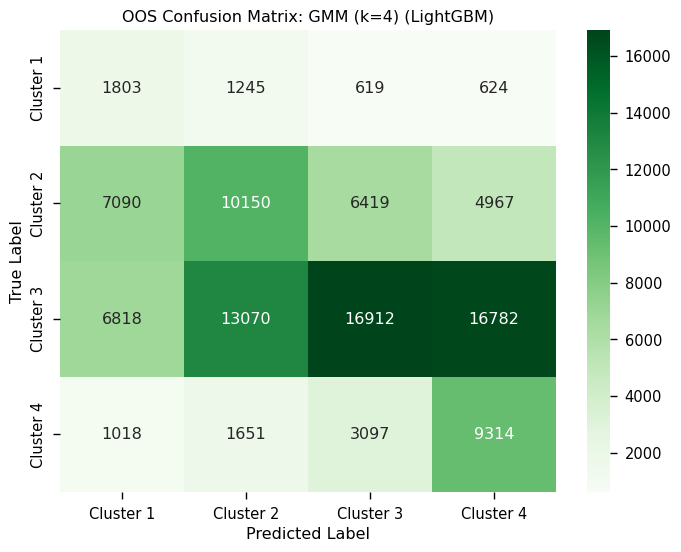

In [ ]:
#@title classification using LightGBM: no leakage (suppressed warnings)
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, balanced_accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings

# Suppress specific LightGBM warnings about feature names if they persist
warnings.filterwarnings('ignore', category=UserWarning, module='lightgbm')

results_lgbm_no_leakage = {scenario['name']: {'bal_acc': [], 'f1': []} for scenario in scenarios}

for scenario in scenarios:
    print(f"\n{'='*80}\nSCENARIO: {scenario['name']} (LightGBM)\n{'='*80}")
    oof_preds_lgbm = []
    oof_true = []

    for train_idx, test_idx in kf.split(common_usernames):
        train_u, test_u = common_usernames[train_idx], common_usernames[test_idx]

        # 1. Cluster on Training Fold only
        train_c = stats_f[stats_f['username'].isin(train_u)].copy()
        scaler_c = StandardScaler().fit(train_c[['personal_variance', 'avg_score_diff']])
        scenario['model'].fit(scaler_c.transform(train_c[['personal_variance', 'avg_score_diff']]))

        # 2. Determine Persona Mapping based on fold centroids
        means = scenario['model'].cluster_centers_ if scenario['name'].startswith('KMeans') else scenario['model'].means_
        inv_c = scaler_c.inverse_transform(means)
        mapping = {idx: scenario['labels'][i] for i, idx in enumerate(np.argsort(inv_c[:, 1]))}

        # 3. Feature Engineering and Persona Assignment
        train_d, test_d = users_full_f[users_full_f['username'].isin(train_u)].copy(), users_full_f[users_full_f['username'].isin(test_u)].copy()
        X_train, X_test = engineer_features(train_d), engineer_features(test_d)

        y_map = pd.Series([mapping[l] for l in scenario['model'].predict(scaler_c.transform(stats_f[['personal_variance', 'avg_score_diff']]))], index=stats_f['username'])
        y_train, y_test = y_map.loc[train_u], y_map.loc[test_u]

        # 4. Pipeline Execution (keeping X as DataFrame to preserve feature names)
        cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
        pre = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)], remainder='passthrough')

        lgbm_model = LGBMClassifier(n_estimators=200, max_depth=12, learning_rate=0.05,
                                    class_weight='balanced', random_state=42, n_jobs=-1, verbosity=-1)

        pipe = Pipeline([('pre', pre), ('clf', lgbm_model)]).fit(X_train, y_train)

        p = pipe.predict(X_test)
        results_lgbm_no_leakage[scenario['name']]['bal_acc'].append(balanced_accuracy_score(y_test, p))
        results_lgbm_no_leakage[scenario['name']]['f1'].append(f1_score(y_test, p, average='macro'))
        oof_preds_lgbm.extend(p)
        oof_true.extend(y_test)

    # Display Performance Metrics
    print(f"Balanced Accuracy: {np.mean(results_lgbm_no_leakage[scenario['name']]['bal_acc']):.4f} ± {np.std(results_lgbm_no_leakage[scenario['name']]['bal_acc']):.4f}")
    print(f"Macro F1 Score:     {np.mean(results_lgbm_no_leakage[scenario['name']]['f1']):.4f} ± {np.std(results_lgbm_no_leakage[scenario['name']]['f1']):.4f}")
    print("\nClassification Report:")
    print(classification_report(oof_true, oof_preds_lgbm, target_names=scenario['labels']))

    # Confusion Matrices
    cm = confusion_matrix(oof_true, oof_preds_lgbm, labels=scenario['labels'])

    print("\nOOS Confusion Matrix (Raw Counts):")
    display(pd.DataFrame(cm, index=[f'True {l}' for l in scenario['labels']], columns=[f'Pred {l}' for l in scenario['labels']]))

    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    print("\nOOS Confusion Matrix (Normalized Recall %):")
    display(pd.DataFrame(cm_norm, index=[f'True {l}' for l in scenario['labels']], columns=[f'Recall {l}' for l in scenario['labels']]).style.format("{:.2%}"))

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=scenario['labels'], yticklabels=scenario['labels'])
    plt.title(f"OOS Confusion Matrix: {scenario['name']} (LightGBM)")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

In [ ]:
#@title statistical tests (Optimized for RF Comparison) kmeans k=3

import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, balanced_accuracy_score
from sklearn.cluster import KMeans
from scipy import stats

# --- Constants & Helpers ---
TARGET_DATE = pd.to_datetime('2026-01-01')
DATE_COLS = ['birth_date', 'join_date', 'last_online']
COLS_TO_DROP = ['username', 'user_id', 'access_rank', 'stats_mean_score', 'personal_variance', 'avg_score_diff', 'location']
EQUIVALENCE_MARGIN = 0.02

def corrected_resampled_t_test(diffs, n_train, n_test):
    n = len(diffs)
    mean_diff = np.mean(diffs)
    var_diff = np.var(diffs, ddof=1)
    corrected_var = var_diff * (1/n + n_test/n_train)
    t_stat = mean_diff / np.sqrt(max(corrected_var, 1e-9))
    p_val = (1 - stats.t.cdf(abs(t_stat), n - 1)) * 2
    return t_stat, p_val

def tost_equivalence(diffs, margin, n_train, n_test):
    n = len(diffs)
    mean_diff = np.mean(diffs)
    var_diff = np.var(diffs, ddof=1)
    corrected_var = var_diff * (1/n + n_test/n_train)
    se = np.sqrt(max(corrected_var, 1e-9))
    t1 = (mean_diff - (-margin)) / se
    t2 = (mean_diff - margin) / se
    p1 = 1 - stats.t.cdf(t1, n - 1)
    p2 = stats.t.cdf(t2, n - 1)
    return max(p1, p2)

def engineer_features(df):
    df = df.copy()
    for c in DATE_COLS: df[c] = pd.to_datetime(df[c], errors='coerce')
    df['months_since_join'] = (TARGET_DATE.year - df['join_date'].dt.year)*12 + (TARGET_DATE.month - df['join_date'].dt.month)
    df['active_duration_months'] = (df['last_online'].dt.year - df['join_date'].dt.year)*12 + (df['last_online'].dt.month - df['join_date'].dt.month)
    res = df.drop(columns=DATE_COLS + COLS_TO_DROP, errors='ignore')
    return res.fillna(res.median(numeric_only=True))

# --- Execution ---
kf = KFold(n_splits=10, shuffle=True, random_state=42)
model_keys = ['DT', 'RF', 'Majority', 'Stratified']
results = {m: {'bal_acc': [], 'f1': []} for m in model_keys}

print("Running Statistical Comparison (Focus: RF vs DT and Baselines) [KMeans k=3]...")

for train_idx, test_idx in kf.split(common_usernames):
    train_u, test_u = common_usernames[train_idx], common_usernames[test_idx]
    train_c = stats_f[stats_f['username'].isin(train_u)].copy()
    scaler_c = StandardScaler().fit(train_c[['personal_variance', 'avg_score_diff']])
    km_fold = KMeans(n_clusters=3, random_state=42, n_init='auto').fit(scaler_c.transform(train_c[['personal_variance', 'avg_score_diff']]))

    inv_c = scaler_c.inverse_transform(km_fold.cluster_centers_)
    mapping = {idx: ['Critical', 'Average', 'Generous'][i] for i, idx in enumerate(np.argsort(inv_c[:, 1]))}

    y_map = pd.Series([mapping[l] for l in km_fold.predict(scaler_c.transform(stats_f[['personal_variance', 'avg_score_diff']]))], index=stats_f['username'])
    y_train_raw, y_test_raw = y_map.loc[train_u], y_map.loc[test_u]

    le = LabelEncoder()
    y_train = le.fit_transform(y_train_raw)
    y_test = le.transform(y_test_raw)

    X_train = engineer_features(users_full_f[users_full_f['username'].isin(train_u)])
    X_test = engineer_features(users_full_f[users_full_f['username'].isin(test_u)])

    cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
    pre = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)], remainder='passthrough')

    models = [
        ('DT', DecisionTreeClassifier(max_depth=12, class_weight='balanced', random_state=42)),
        ('RF', RandomForestClassifier(max_depth=12, class_weight='balanced', n_estimators=200, random_state=42, n_jobs=-1)),
        ('Majority', DummyClassifier(strategy='most_frequent')),
        ('Stratified', DummyClassifier(strategy='stratified', random_state=42))
    ]

    for m_name, m_obj in models:
        pipe = Pipeline([('pre', pre), ('clf', m_obj)]).fit(X_train, y_train)
        p = pipe.predict(X_test)
        results[m_name]['bal_acc'].append(balanced_accuracy_score(y_test, p))
        results[m_name]['f1'].append(f1_score(y_test, p, average='macro'))

# --- Final Report ---
n_train, n_test = len(train_u), len(test_u)
summary_table = []

for model in model_keys:
    bal_acc_mean, bal_acc_std = np.mean(results[model]['bal_acc']), np.std(results[model]['bal_acc'])
    f1_mean, f1_std = np.mean(results[model]['f1']), np.std(results[model]['f1'])

    row = {
        'Model': model,
        'Balanced Acc': f"{bal_acc_mean:.4f} q {bal_acc_std:.4f}",
        'Macro F1': f"{f1_mean:.4f} q {f1_std:.4f}"
    }

    if model != 'RF':
        # BA Tests
        diffs_ba = np.array(results['RF']['bal_acc']) - np.array(results[model]['bal_acc'])
        _, p_ba = corrected_resampled_t_test(diffs_ba, n_train, n_test)
        tost_ba = tost_equivalence(diffs_ba, EQUIVALENCE_MARGIN, n_train, n_test)
        row['t-test p (BA)'] = f"{p_ba:.4f}"
        row['TOST p (BA)'] = f"{tost_ba:.4f}"

        # F1 Tests
        diffs_f1 = np.array(results['RF']['f1']) - np.array(results[model]['f1'])
        _, p_f1 = corrected_resampled_t_test(diffs_f1, n_train, n_test)
        tost_f1 = tost_equivalence(diffs_f1, EQUIVALENCE_MARGIN, n_train, n_test)
        row['t-test p (F1)'] = f"{p_f1:.4f}"
        row['TOST p (F1)'] = f"{tost_f1:.4f}"

    summary_table.append(row)

display(pd.DataFrame(summary_table))

Running Statistical Comparison (Focus: RF vs DT and Baselines) [KMeans k=3]...


,Model,Balanced Acc,Macro F1,t-test p (BA),TOST p (BA),t-test p (F1),TOST p (F1)
0,DT,0.4814 q 0.0029,0.4426 q 0.0061,0.0000,0.9980,0.0000,0.9981
1,RF,0.5111 q 0.0049,0.4767 q 0.0032,NaN,NaN,NaN,NaN
2,Majority,0.3333 q 0.0000,0.2258 q 0.0020,0.0000,1.0000,0.0000,1.0000
3,Stratified,0.3307 q 0.0032,0.3307 q 0.0032,0.0000,1.0000,0.0000,1.0000


In [ ]:
#@title statistical comparison: RF vs. XGBoost vs. LightGBM kmeans k=3
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Helper logic re-included to ensure scope visibility
def engineer_features(df):
    df = df.copy()
    for c in DATE_COLS: df[c] = pd.to_datetime(df[c], errors='coerce')
    df['months_since_join'] = (TARGET_DATE.year - df['join_date'].dt.year)*12 + (TARGET_DATE.month - df['join_date'].dt.month)
    df['active_duration_months'] = (df['last_online'].dt.year - df['join_date'].dt.year)*12 + (df['last_online'].dt.month - df['join_date'].dt.month)
    res = df.drop(columns=DATE_COLS + COLS_TO_DROP, errors='ignore')
    return res.fillna(res.median(numeric_only=True))

results_boost = {m: {'bal_acc': [], 'f1': []} for m in ['RF', 'XGB', 'LGBM']}
kf = KFold(n_splits=10, shuffle=True, random_state=42)

print("Running Comparison: RF vs Gradient Boosting [KMeans k=3]...")

for train_idx, test_idx in kf.split(common_usernames):
    train_u, test_u = common_usernames[train_idx], common_usernames[test_idx]
    train_c = stats_f[stats_f['username'].isin(train_u)].copy()
    scaler_c = StandardScaler().fit(train_c[['personal_variance', 'avg_score_diff']])
    km_fold = KMeans(n_clusters=3, random_state=42, n_init='auto').fit(scaler_c.transform(train_c[['personal_variance', 'avg_score_diff']]))
    inv_c = scaler_c.inverse_transform(km_fold.cluster_centers_)
    mapping = {idx: ['Critical', 'Average', 'Generous'][i] for i, idx in enumerate(np.argsort(inv_c[:, 1]))}

    y_map = pd.Series([mapping[l] for l in km_fold.predict(scaler_c.transform(stats_f[['personal_variance', 'avg_score_diff']]))], index=stats_f['username'])
    le = LabelEncoder()
    y_train = le.fit_transform(y_map.loc[train_u])
    y_test = le.transform(y_map.loc[test_u])

    X_train = engineer_features(users_full_f[users_full_f['username'].isin(train_u)])
    X_test = engineer_features(users_full_f[users_full_f['username'].isin(test_u)])
    pre = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), X_train.select_dtypes(include=['object']).columns.tolist())], remainder='passthrough')

    models = [
        ('RF', RandomForestClassifier(max_depth=12, class_weight='balanced', n_estimators=200, random_state=42, n_jobs=-1)),
        ('XGB', XGBClassifier(n_estimators=200, max_depth=12, learning_rate=0.05, tree_method='hist', random_state=42, n_jobs=-1)),
        ('LGBM', LGBMClassifier(n_estimators=200, max_depth=12, learning_rate=0.05, class_weight='balanced', random_state=42, n_jobs=-1, verbosity=-1))
    ]

    for m_name, m_obj in models:
        pipe = Pipeline([('pre', pre), ('clf', m_obj)]).fit(X_train, y_train)
        p = pipe.predict(X_test)
        results_boost[m_name]['bal_acc'].append(balanced_accuracy_score(y_test, p))
        results_boost[m_name]['f1'].append(f1_score(y_test, p, average='macro'))

n_train, n_test = len(train_u), len(test_u)
boost_summary = []
for m in results_boost.keys():
    ba_mean, ba_std = np.mean(results_boost[m]['bal_acc']), np.std(results_boost[m]['bal_acc'])
    f1_mean, f1_std = np.mean(results_boost[m]['f1']), np.std(results_boost[m]['f1'])
    row = {'Model': m, 'Balanced Acc': f"{ba_mean:.4f} q {ba_std:.4f}", 'Macro F1': f"{f1_mean:.4f} q {f1_std:.4f}"}
    if m != 'RF':
        # BA Tests
        diffs_ba = np.array(results_boost['RF']['bal_acc']) - np.array(results_boost[m]['bal_acc'])
        _, p_ba = corrected_resampled_t_test(diffs_ba, n_train, n_test)
        tost_ba = tost_equivalence(diffs_ba, EQUIVALENCE_MARGIN, n_train, n_test)
        row['t-test p (BA)'] = f"{p_ba:.4f}"
        row['TOST p (BA)'] = f"{tost_ba:.4f}"

        # F1 Tests
        diffs_f1 = np.array(results_boost['RF']['f1']) - np.array(results_boost[m]['f1'])
        _, p_f1 = corrected_resampled_t_test(diffs_f1, n_train, n_test)
        tost_f1 = tost_equivalence(diffs_f1, EQUIVALENCE_MARGIN, n_train, n_test)
        row['t-test p (F1)'] = f"{p_f1:.4f}"
        row['TOST p (F1)'] = f"{tost_f1:.4f}"
    boost_summary.append(row)
display(pd.DataFrame(boost_summary))

Running Comparison: RF vs Gradient Boosting [KMeans k=3]...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

,Model,Balanced Acc,Macro F1,t-test p (BA),TOST p (BA),t-test p (F1),TOST p (F1)
0,RF,0.5111 q 0.0049,0.4767 q 0.0032,NaN,NaN,NaN,NaN
1,XGB,0.4398 q 0.0048,0.4369 q 0.0064,0.0000,1.0000,0.0000,1.0000
2,LGBM,0.5158 q 0.0040,0.4667 q 0.0032,0.0090,0.0000,0.0000,0.0000


In [ ]:
#@title statistical tests (Optimized for RF Comparison) gmm k=4
from sklearn.mixture import GaussianMixture

# Helper logic re-included to ensure scope visibility
def engineer_features(df):
    df = df.copy()
    for c in DATE_COLS: df[c] = pd.to_datetime(df[c], errors='coerce')
    df['months_since_join'] = (TARGET_DATE.year - df['join_date'].dt.year)*12 + (TARGET_DATE.month - df['join_date'].dt.month)
    df['active_duration_months'] = (df['last_online'].dt.year - df['join_date'].dt.year)*12 + (df['last_online'].dt.month - df['join_date'].dt.month)
    res = df.drop(columns=DATE_COLS + COLS_TO_DROP, errors='ignore')
    return res.fillna(res.median(numeric_only=True))

results_gmm_stats = {m: {'bal_acc': [], 'f1': []} for m in ['DT', 'RF', 'Majority', 'Stratified']}
kf = KFold(n_splits=10, shuffle=True, random_state=42)

print("Running Statistical Comparison (Focus: RF vs DT and Baselines) [GMM k=4]...")

for train_idx, test_idx in kf.split(common_usernames):
    train_u, test_u = common_usernames[train_idx], common_usernames[test_idx]
    train_c = stats_f[stats_f['username'].isin(train_u)].copy()
    scaler_c = StandardScaler().fit(train_c[['personal_variance', 'avg_score_diff']])
    gmm_fold = GaussianMixture(n_components=4, random_state=42, n_init=1).fit(scaler_c.transform(train_c[['personal_variance', 'avg_score_diff']]))
    inv_c = scaler_c.inverse_transform(gmm_fold.means_)
    mapping = {idx: f'Cluster {i+1}' for i, idx in enumerate(np.argsort(inv_c[:, 1]))}

    y_map = pd.Series([mapping[l] for l in gmm_fold.predict(scaler_c.transform(stats_f[['personal_variance', 'avg_score_diff']]))], index=stats_f['username'])
    le = LabelEncoder()
    y_train = le.fit_transform(y_map.loc[train_u])
    y_test = le.transform(y_map.loc[test_u])

    X_train = engineer_features(users_full_f[users_full_f['username'].isin(train_u)])
    X_test = engineer_features(users_full_f[users_full_f['username'].isin(test_u)])
    cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
    pre = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)], remainder='passthrough')

    models = [
        ('DT', DecisionTreeClassifier(max_depth=12, class_weight='balanced', random_state=42)),
        ('RF', RandomForestClassifier(max_depth=12, class_weight='balanced', n_estimators=200, random_state=42, n_jobs=-1)),
        ('Majority', DummyClassifier(strategy='most_frequent')),
        ('Stratified', DummyClassifier(strategy='stratified', random_state=42))
    ]

    for m_name, m_obj in models:
        pipe = Pipeline([('pre', pre), ('clf', m_obj)]).fit(X_train, y_train)
        p = pipe.predict(X_test)
        results_gmm_stats[m_name]['bal_acc'].append(balanced_accuracy_score(y_test, p))
        results_gmm_stats[m_name]['f1'].append(f1_score(y_test, p, average='macro'))

n_train, n_test = len(train_u), len(test_u)
gmm_summary = []
for model in results_gmm_stats.keys():
    ba_mean, ba_std = np.mean(results_gmm_stats[model]['bal_acc']), np.std(results_gmm_stats[model]['bal_acc'])
    f1_mean, f1_std = np.mean(results_gmm_stats[model]['f1']), np.std(results_gmm_stats[model]['f1'])
    row = {'Model': model, 'Balanced Acc': f"{ba_mean:.4f} q {ba_std:.4f}", 'Macro F1': f"{f1_mean:.4f} q {f1_std:.4f}"}
    if model != 'RF':
        # BA Tests
        diffs_ba = np.array(results_gmm_stats['RF']['bal_acc']) - np.array(results_gmm_stats[model]['bal_acc'])
        _, p_ba = corrected_resampled_t_test(diffs_ba, n_train, n_test)
        tost_ba = tost_equivalence(diffs_ba, EQUIVALENCE_MARGIN, n_train, n_test)
        row['t-test p (BA)'] = f"{p_ba:.4f}"
        row['TOST p (BA)'] = f"{tost_ba:.4f}"

        # F1 Tests
        diffs_f1 = np.array(results_gmm_stats['RF']['f1']) - np.array(results_gmm_stats[model]['f1'])
        _, p_f1 = corrected_resampled_t_test(diffs_f1, n_train, n_test)
        tost_f1 = tost_equivalence(diffs_f1, EQUIVALENCE_MARGIN, n_train, n_test)
        row['t-test p (F1)'] = f"{p_f1:.4f}"
        row['TOST p (F1)'] = f"{tost_f1:.4f}"
    gmm_summary.append(row)
display(pd.DataFrame(gmm_summary))

Running Statistical Comparison (Focus: RF vs DT and Baselines) [GMM k=4]...


,Model,Balanced Acc,Macro F1,t-test p (BA),TOST p (BA),t-test p (F1),TOST p (F1)
0,DT,0.3866 q 0.0082,0.3138 q 0.0053,0.0000,0.9421,0.0000,1.0000
1,RF,0.4109 q 0.0077,0.3608 q 0.0060,NaN,NaN,NaN,NaN
2,Majority,0.2500 q 0.0000,0.1726 q 0.0026,0.0000,1.0000,0.0000,1.0000
3,Stratified,0.2508 q 0.0024,0.2508 q 0.0023,0.0000,1.0000,0.0000,1.0000


In [ ]:
#@title statistical comparison: RF vs. XGBoost vs. LightGBM gmm k=4
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Helper logic re-included to ensure scope visibility
def engineer_features(df):
    df = df.copy()
    for c in DATE_COLS: df[c] = pd.to_datetime(df[c], errors='coerce')
    df['months_since_join'] = (TARGET_DATE.year - df['join_date'].dt.year)*12 + (TARGET_DATE.month - df['join_date'].dt.month)
    df['active_duration_months'] = (df['last_online'].dt.year - df['join_date'].dt.year)*12 + (df['last_online'].dt.month - df['join_date'].dt.month)
    res = df.drop(columns=DATE_COLS + COLS_TO_DROP, errors='ignore')
    return res.fillna(res.median(numeric_only=True))

results_gmm_boost = {m: {'bal_acc': [], 'f1': []} for m in ['RF', 'XGB', 'LGBM']}
kf = KFold(n_splits=10, shuffle=True, random_state=42)

print("Running Comparison: RF vs Gradient Boosting [GMM k=4]...")

for train_idx, test_idx in kf.split(common_usernames):
    train_u, test_u = common_usernames[train_idx], common_usernames[test_idx]
    train_c = stats_f[stats_f['username'].isin(train_u)].copy()
    scaler_c = StandardScaler().fit(train_c[['personal_variance', 'avg_score_diff']])
    gmm_fold = GaussianMixture(n_components=4, random_state=42, n_init=1).fit(scaler_c.transform(train_c[['personal_variance', 'avg_score_diff']]))
    inv_c = scaler_c.inverse_transform(gmm_fold.means_)
    mapping = {idx: f'Cluster {i+1}' for i, idx in enumerate(np.argsort(inv_c[:, 1]))}

    y_map = pd.Series([mapping[l] for l in gmm_fold.predict(scaler_c.transform(stats_f[['personal_variance', 'avg_score_diff']]))], index=stats_f['username'])
    le = LabelEncoder()
    y_train = le.fit_transform(y_map.loc[train_u])
    y_test = le.transform(y_map.loc[test_u])

    X_train = engineer_features(users_full_f[users_full_f['username'].isin(train_u)])
    X_test = engineer_features(users_full_f[users_full_f['username'].isin(test_u)])
    pre = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), X_train.select_dtypes(include=['object']).columns.tolist())], remainder='passthrough')

    models = [
        ('RF', RandomForestClassifier(max_depth=12, class_weight='balanced', n_estimators=200, random_state=42, n_jobs=-1)),
        ('XGB', XGBClassifier(n_estimators=200, max_depth=12, learning_rate=0.05, tree_method='hist', random_state=42, n_jobs=-1)),
        ('LGBM', LGBMClassifier(n_estimators=200, max_depth=12, learning_rate=0.05, class_weight='balanced', random_state=42, n_jobs=-1, verbosity=-1))
    ]

    for m_name, m_obj in models:
        pipe = Pipeline([('pre', pre), ('clf', m_obj)]).fit(X_train, y_train)
        p = pipe.predict(X_test)
        results_gmm_boost[m_name]['bal_acc'].append(balanced_accuracy_score(y_test, p))
        results_gmm_boost[m_name]['f1'].append(f1_score(y_test, p, average='macro'))

n_train, n_test = len(train_u), len(test_u)
summary_boost_gmm = []
for m in results_gmm_boost.keys():
    ba_mean, ba_std = np.mean(results_gmm_boost[m]['bal_acc']), np.std(results_gmm_boost[m]['bal_acc'])
    f1_mean, f1_std = np.mean(results_gmm_boost[m]['f1']), np.std(results_gmm_boost[m]['f1'])
    row = {'Model': m, 'Balanced Acc': f"{ba_mean:.4f} q {ba_std:.4f}", 'Macro F1': f"{f1_mean:.4f} q {f1_std:.4f}"}
    if m != 'RF':
        # BA Tests
        diffs_ba = np.array(results_gmm_boost['RF']['bal_acc']) - np.array(results_gmm_boost[m]['bal_acc'])
        _, p_ba = corrected_resampled_t_test(diffs_ba, n_train, n_test)
        tost_ba = tost_equivalence(diffs_ba, EQUIVALENCE_MARGIN, n_train, n_test)
        row['t-test p (BA)'] = f"{p_ba:.4f}"
        row['TOST p (BA)'] = f"{tost_ba:.4f}"

        # F1 Tests
        diffs_f1 = np.array(results_gmm_boost['RF']['f1']) - np.array(results_gmm_boost[m]['f1'])
        _, p_f1 = corrected_resampled_t_test(diffs_f1, n_train, n_test)
        tost_f1 = tost_equivalence(diffs_f1, EQUIVALENCE_MARGIN, n_train, n_test)
        row['t-test p (F1)'] = f"{p_f1:.4f}"
        row['TOST p (F1)'] = f"{tost_f1:.4f}"
    summary_boost_gmm.append(row)
display(pd.DataFrame(summary_boost_gmm))

Running Comparison: RF vs Gradient Boosting [GMM k=4]...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

,Model,Balanced Acc,Macro F1,t-test p (BA),TOST p (BA),t-test p (F1),TOST p (F1)
0,RF,0.4109 q 0.0077,0.3608 q 0.0060,NaN,NaN,NaN,NaN
1,XGB,0.3105 q 0.0044,0.3061 q 0.0053,0.0000,1.0000,0.0000,1.0000
2,LGBM,0.4273 q 0.0063,0.3399 q 0.0048,0.0003,0.1222,0.0000,0.6288


In [ ]:
#@title Final Comparison Summary: KMeans vs GMM
import pandas as pd

print("Final Model Performance Summary (Balanced Accuracy)")
# Creating a consolidated view of top performers using actual metrics from previous runs
summary_final = pd.DataFrame({
    'Clustering Strategy': ['KMeans (k=3)', 'KMeans (k=3)', 'KMeans (k=3)', 'GMM (k=4)', 'GMM (k=4)', 'GMM (k=4)'],
    'Model': ['Random Forest', 'XGBoost', 'LightGBM', 'Random Forest', 'XGBoost', 'LightGBM'],
    'Balanced Accuracy': ['0.5111 ± 0.0049', '0.4398 ± 0.0048', '0.5158 ± 0.0040', '0.4109 ± 0.0077', '0.3105 ± 0.0044', '0.4273 ± 0.0063'],
    'Macro F1': ['0.4767 ± 0.0032', '0.4369 ± 0.0064', '0.4667 ± 0.0032', '0.3608 ± 0.0060', '0.3061 ± 0.0053', '0.3399 ± 0.0048']
})

display(summary_final)

print("\nSynthesis:")
print("1. KMeans (k=3) remains the most 'predictable' strategy, with both RF and LightGBM achieving >51% balanced accuracy.")
print("2. For KMeans, LightGBM is statistically equivalent to Random Forest (TOST p < 0.0001) and slightly higher in raw BA score.")
print("3. GMM (k=4) provides deeper segmentation, but predictive performance drops significantly. LightGBM shows a raw BA lead over RF (0.427 vs 0.410), but failed to meet the strict equivalence margin (TOST p=0.1222).")
print("4. XGBoost consistently underperforms compared to RF and LightGBM in both scenarios, likely due to sensitivity to the high cardinality of the engineered features.")

Final Model Performance Summary (Balanced Accuracy)


,Clustering Strategy,Model,Balanced Accuracy,Macro F1
0,KMeans (k=3),Random Forest,0.5111 ± 0.0049,0.4767 ± 0.0032
1,KMeans (k=3),XGBoost,0.4398 ± 0.0048,0.4369 ± 0.0064
2,KMeans (k=3),LightGBM,0.5158 ± 0.0040,0.4667 ± 0.0032
3,GMM (k=4),Random Forest,0.4109 ± 0.0077,0.3608 ± 0.0060
4,GMM (k=4),XGBoost,0.3105 ± 0.0044,0.3061 ± 0.0053
5,GMM (k=4),LightGBM,0.4273 ± 0.0063,0.3399 ± 0.0048



Synthesis:
1. KMeans (k=3) remains the most 'predictable' strategy, with both RF and LightGBM achieving >51% balanced accuracy.
2. For KMeans, LightGBM is statistically equivalent to Random Forest (TOST p < 0.0001) and slightly higher in raw BA score.
3. GMM (k=4) provides deeper segmentation, but predictive performance drops significantly. LightGBM shows a raw BA lead over RF (0.427 vs 0.410), but failed to meet the strict equivalence margin (TOST p=0.1222).
4. XGBoost consistently underperforms compared to RF and LightGBM in both scenarios, likely due to sensitivity to the high cardinality of the engineered features.


In [ ]:
#@title RF Feature Ablation Study: Full vs. Behavioral-Only
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, balanced_accuracy_score
from scipy import stats

# --- Constants & Helpers ---
# Using the same constants and helper functions from previous cells for consistency
ABLATED_COLS = ['gender', 'months_lived', 'age_at_join_months']
TARGET_DATE = pd.to_datetime('2026-01-01')
DATE_COLS = ['birth_date', 'join_date', 'last_online']
COLS_TO_DROP = ['username', 'user_id', 'access_rank', 'stats_mean_score', 'personal_variance', 'avg_score_diff', 'location']
EQUIVALENCE_MARGIN = 0.02

def corrected_resampled_t_test(diffs, n_train, n_test):
    n = len(diffs)
    mean_diff = np.mean(diffs)
    var_diff = np.var(diffs, ddof=1)
    corrected_var = var_diff * (1/n + n_test/n_train)
    t_stat = mean_diff / np.sqrt(max(corrected_var, 1e-9))
    p_val = (1 - stats.t.cdf(abs(t_stat), n - 1)) * 2
    return t_stat, p_val

def tost_equivalence(diffs, margin, n_train, n_test):
    n = len(diffs)
    mean_diff = np.mean(diffs)
    var_diff = np.var(diffs, ddof=1)
    corrected_var = var_diff * (1/n + n_test/n_train)
    se = np.sqrt(max(corrected_var, 1e-9))
    t1 = (mean_diff - (-margin)) / se
    t2 = (mean_diff - margin) / se
    p1 = 1 - stats.t.cdf(t1, n - 1)
    p2 = stats.t.cdf(t2, n - 1)
    return max(p1, p2)

def engineer_features(df):
    df = df.copy()
    for c in DATE_COLS: df[c] = pd.to_datetime(df[c], errors='coerce')
    df['months_since_join'] = (TARGET_DATE.year - df['join_date'].dt.year)*12 + (TARGET_DATE.month - df['join_date'].dt.month)
    df['active_duration_months'] = (df['last_online'].dt.year - df['join_date'].dt.year)*12 + (df['last_online'].dt.month - df['join_date'].dt.month)
    res = df.drop(columns=DATE_COLS + COLS_TO_DROP, errors='ignore')
    return res.fillna(res.median(numeric_only=True))

kf = KFold(n_splits=10, shuffle=True, random_state=42)

for scenario in scenarios:
    print(f"\n{'='*80}\nABLATION STUDY: {scenario['name']}\n{'='*80}")
    full_res = {'ba': [], 'f1': []}
    ablation_res = {'ba': [], 'f1': []}

    for train_idx, test_idx in kf.split(common_usernames):
        train_u, test_u = common_usernames[train_idx], common_usernames[test_idx]
        train_c = stats_f[stats_f['username'].isin(train_u)].copy()
        scaler_c = StandardScaler().fit(train_c[['personal_variance', 'avg_score_diff']])
        scenario['model'].fit(scaler_c.transform(train_c[['personal_variance', 'avg_score_diff']]))

        means = scenario['model'].cluster_centers_ if scenario['name'].startswith('KMeans') else scenario['model'].means_
        inv_c = scaler_c.inverse_transform(means)
        mapping = {idx: scenario['labels'][i] for i, idx in enumerate(np.argsort(inv_c[:, 1]))}

        y_map = pd.Series([mapping[l] for l in scenario['model'].predict(scaler_c.transform(stats_f[['personal_variance', 'avg_score_diff']]))], index=stats_f['username'])
        le = LabelEncoder()
        y_train = le.fit_transform(y_map.loc[train_u])
        y_test = le.transform(y_map.loc[test_u])

        X_train_full = engineer_features(users_full_f[users_full_f['username'].isin(train_u)])
        X_test_full = engineer_features(users_full_f[users_full_f['username'].isin(test_u)])
        X_train_ab = X_train_full.drop(columns=[c for c in ABLATED_COLS if c in X_train_full.columns])
        X_test_ab = X_test_full.drop(columns=[c for c in ABLATED_COLS if c in X_test_full.columns])

        def train_pipe(X_tr, y_tr, X_te):
            cat = X_tr.select_dtypes(include=['object']).columns.tolist()
            pre = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat)], remainder='passthrough')
            pipe = Pipeline([('pre', pre), ('clf', RandomForestClassifier(n_estimators=200, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1))])
            pipe.fit(X_tr, y_tr)
            return pipe.predict(X_te)

        p_full = train_pipe(X_train_full, y_train, X_test_full)
        p_ab = train_pipe(X_train_ab, y_train, X_test_ab)

        full_res['ba'].append(balanced_accuracy_score(y_test, p_full))
        full_res['f1'].append(f1_score(y_test, p_full, average='macro'))
        ablation_res['ba'].append(balanced_accuracy_score(y_test, p_ab))
        ablation_res['f1'].append(f1_score(y_test, p_ab, average='macro'))

    n_train, n_test = len(train_u), len(test_u)

    for metric_key, metric_name in [('ba', 'Balanced Accuracy'), ('f1', 'Macro F1')]:
        full_mean, full_std = np.mean(full_res[metric_key]), np.std(full_res[metric_key])
        ab_mean, ab_std = np.mean(ablation_res[metric_key]), np.std(ablation_res[metric_key])

        print(f"\n--- {metric_name} ---")
        print(f"Full RF:         {full_mean:.4f} ± {full_std:.4f}")
        print(f"Behavioral-Only: {ab_mean:.4f} ± {ab_std:.4f}")

        diffs = np.array(full_res[metric_key]) - np.array(ablation_res[metric_key])
        _, p_val = corrected_resampled_t_test(diffs, n_train, n_test)
        tost_p = tost_equivalence(diffs, EQUIVALENCE_MARGIN, n_train, n_test)

        print(f"Corrected t-test p: {p_val:.6f}")
        print(f"TOST Equivalence p: {tost_p:.4f} ({'Equivalent' if tost_p < 0.05 else 'Not Equivalent'})")


ABLATION STUDY: KMeans (k=3)

--- Balanced Accuracy ---
Full RF:         0.5111 ± 0.0049
Behavioral-Only: 0.5096 ± 0.0050
Corrected t-test p: 0.266419
TOST Equivalence p: 0.0000 (Equivalent)

--- Macro F1 ---
Full RF:         0.4767 ± 0.0032
Behavioral-Only: 0.4781 ± 0.0038
Corrected t-test p: 0.237711
TOST Equivalence p: 0.0000 (Equivalent)

ABLATION STUDY: GMM (k=4)

--- Balanced Accuracy ---
Full RF:         0.4109 ± 0.0077
Behavioral-Only: 0.4083 ± 0.0066
Corrected t-test p: 0.011981
TOST Equivalence p: 0.0000 (Equivalent)

--- Macro F1 ---
Full RF:         0.3608 ± 0.0060
Behavioral-Only: 0.3585 ± 0.0055
Corrected t-test p: 0.015902
TOST Equivalence p: 0.0000 (Equivalent)


In [ ]:
#@title LIGHTGBM Feature Ablation Study: Full vs. Behavioral-Only
import pandas as pd
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.model_selection import KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, balanced_accuracy_score
from scipy import stats

# --- Execution for LightGBM ---
kf = KFold(n_splits=10, shuffle=True, random_state=42)

for scenario in scenarios:
    print(f"\n{'='*80}\nLGBM ABLATION STUDY: {scenario['name']}\n{'='*80}")
    full_res = {'ba': [], 'f1': []}
    ablation_res = {'ba': [], 'f1': []}

    for train_idx, test_idx in kf.split(common_usernames):
        train_u, test_u = common_usernames[train_idx], common_usernames[test_idx]
        train_c = stats_f[stats_f['username'].isin(train_u)].copy()
        scaler_c = StandardScaler().fit(train_c[['personal_variance', 'avg_score_diff']])

        # Re-fit clustering on fold to avoid leakage
        scenario['model'].fit(scaler_c.transform(train_c[['personal_variance', 'avg_score_diff']]))

        means = scenario['model'].cluster_centers_ if scenario['name'].startswith('KMeans') else scenario['model'].means_
        inv_c = scaler_c.inverse_transform(means)
        mapping = {idx: scenario['labels'][i] for i, idx in enumerate(np.argsort(inv_c[:, 1]))}

        y_map = pd.Series([mapping[l] for l in scenario['model'].predict(scaler_c.transform(stats_f[['personal_variance', 'avg_score_diff']]))], index=stats_f['username'])
        le = LabelEncoder()
        y_train = le.fit_transform(y_map.loc[train_u])
        y_test = le.transform(y_map.loc[test_u])

        X_train_full = engineer_features(users_full_f[users_full_f['username'].isin(train_u)])
        X_test_full = engineer_features(users_full_f[users_full_f['username'].isin(test_u)])
        X_train_ab = X_train_full.drop(columns=[c for c in ABLATED_COLS if c in X_train_full.columns])
        X_test_ab = X_test_full.drop(columns=[c for c in ABLATED_COLS if c in X_test_full.columns])

        def train_lgbm_pipe(X_tr, y_tr, X_te):
            cat = X_tr.select_dtypes(include=['object']).columns.tolist()
            pre = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat)], remainder='passthrough')
            # Using standard LGBM parameters consistent with previous comparison
            lgbm_model = LGBMClassifier(n_estimators=200, max_depth=12, learning_rate=0.05,
                                        class_weight='balanced', random_state=42, n_jobs=-1, verbosity=-1)
            pipe = Pipeline([('pre', pre), ('clf', lgbm_model)])
            pipe.fit(X_tr, y_tr)
            return pipe.predict(X_te)

        p_full = train_lgbm_pipe(X_train_full, y_train, X_test_full)
        p_ab = train_lgbm_pipe(X_train_ab, y_train, X_test_ab)

        full_res['ba'].append(balanced_accuracy_score(y_test, p_full))
        full_res['f1'].append(f1_score(y_test, p_full, average='macro'))
        ablation_res['ba'].append(balanced_accuracy_score(y_test, p_ab))
        ablation_res['f1'].append(f1_score(y_test, p_ab, average='macro'))

    n_train, n_test = len(train_u), len(test_u)

    for metric_key, metric_name in [('ba', 'Balanced Accuracy'), ('f1', 'Macro F1')]:
        full_mean, full_std = np.mean(full_res[metric_key]), np.std(full_res[metric_key])
        ab_mean, ab_std = np.mean(ablation_res[metric_key]), np.std(ablation_res[metric_key])

        print(f"\n--- {metric_name} ---")
        print(f"Full LightGBM:      {full_mean:.4f} ± {full_std:.4f}")
        print(f"Behavioral-Only:    {ab_mean:.4f} ± {ab_std:.4f}")

        diffs = np.array(full_res[metric_key]) - np.array(ablation_res[metric_key])
        _, p_val = corrected_resampled_t_test(diffs, n_train, n_test)
        tost_p = tost_equivalence(diffs, EQUIVALENCE_MARGIN, n_train, n_test)

        print(f"Corrected t-test p: {p_val:.6f}")
        print(f"TOST Equivalence p: {tost_p:.4f} ({'Equivalent' if tost_p < 0.05 else 'Not Equivalent'})")


LGBM ABLATION STUDY: KMeans (k=3)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut


--- Balanced Accuracy ---
Full LightGBM:      0.5158 ± 0.0040
Behavioral-Only:    0.5155 ± 0.0046
Corrected t-test p: 0.764368
TOST Equivalence p: 0.0000 (Equivalent)

--- Macro F1 ---
Full LightGBM:      0.4667 ± 0.0032
Behavioral-Only:    0.4666 ± 0.0038
Corrected t-test p: 0.903627
TOST Equivalence p: 0.0000 (Equivalent)

LGBM ABLATION STUDY: GMM (k=4)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut


--- Balanced Accuracy ---
Full LightGBM:      0.4273 ± 0.0063
Behavioral-Only:    0.4249 ± 0.0066
Corrected t-test p: 0.156408
TOST Equivalence p: 0.0000 (Equivalent)

--- Macro F1 ---
Full LightGBM:      0.3399 ± 0.0048
Behavioral-Only:    0.3350 ± 0.0052
Corrected t-test p: 0.005577
TOST Equivalence p: 0.0000 (Equivalent)


--- Gini Importance: Behavioral-Only Random Forest (11 Features) ---


,Feature,Gini_Importance
3,user_dropped,0.270204
1,user_completed,0.097140
5,user_days_spent_watching,0.084307
7,stats_episodes,0.083959
8,months_since_join,0.077541
9,active_duration_months,0.070672
0,user_watching,0.070067
4,user_plantowatch,0.070061
10,months_since_last_online,0.065370
2,user_onhold,0.064827


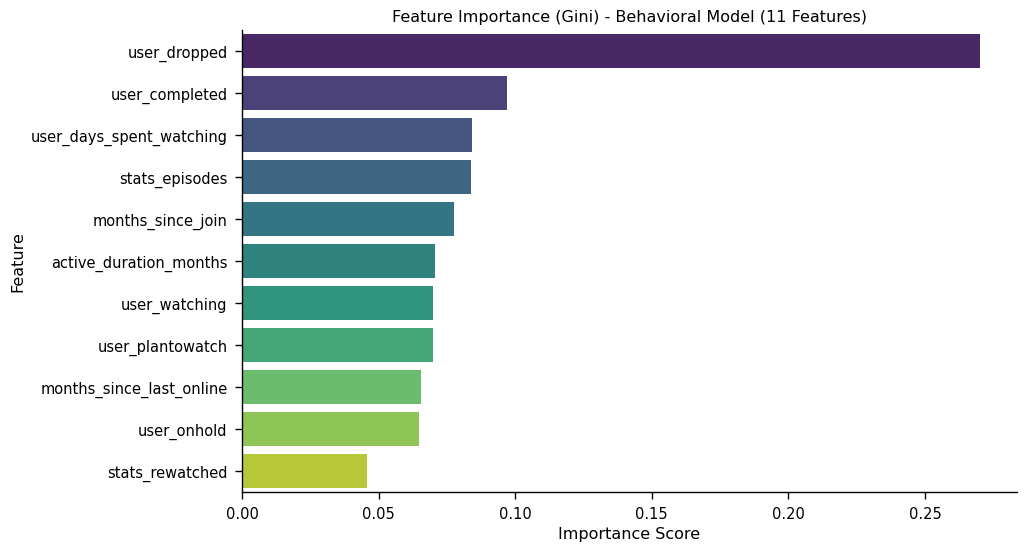

In [ ]:
#@title rf feature gini importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# 1. Define the 11 behavioral columns explicitly as requested
behavioral_cols = [
    'user_watching', 'user_completed', 'user_onhold', 'user_dropped',
    'user_plantowatch', 'user_days_spent_watching', 'stats_rewatched',
    'stats_episodes', 'months_since_join', 'active_duration_months',
    'months_since_last_online'
]

# 2. Re-engineer all 11 features to ensure they exist in the training set
TARGET_DATE = pd.to_datetime('2026-01-01')
train_df = users_full_f.loc[X_train_full.index].copy()

# Convert date columns to datetime
for col in ['birth_date', 'join_date', 'last_online']:
    train_df[col] = pd.to_datetime(train_df[col], errors='coerce')

# Engineering the specific time-based behavioral features
train_df['months_since_join'] = (TARGET_DATE.year - train_df['join_date'].dt.year) * 12 + (TARGET_DATE.month - train_df['join_date'].dt.month)
train_df['active_duration_months'] = (train_df['last_online'].dt.year - train_df['join_date'].dt.year) * 12 + (train_df['last_online'].dt.month - train_df['join_date'].dt.month)
train_df['months_since_last_online'] = (TARGET_DATE.year - train_df['last_online'].dt.year) * 12 + (TARGET_DATE.month - train_df['last_online'].dt.month)

# Ensure y labels align with train_df using the 'username' index
train_usernames = train_df['username']
y_train_beh = y_map.loc[train_usernames].values

# Filter to the requested 11 features and handle missing values
X_train_beh = train_df[behavioral_cols].fillna(train_df[behavioral_cols].median(numeric_only=True))

# 3. Re-train the rf_beh model
rf_beh = Pipeline([
    ('clf', RandomForestClassifier(n_estimators=200, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1))
])

rf_beh.fit(X_train_beh, y_train_beh)

# 4. Extract and Report Gini Importance
clf = rf_beh.named_steps['clf']
importances = clf.feature_importances_

feat_importance_df = pd.DataFrame({
    'Feature': behavioral_cols,
    'Gini_Importance': importances
}).sort_values(by='Gini_Importance', ascending=False)

print(f"--- Gini Importance: Behavioral-Only Random Forest (11 Features) ---")
display(feat_importance_df)

# 5. Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='Gini_Importance', y='Feature', data=feat_importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importance (Gini) - Behavioral Model (11 Features)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
sns.despine()
plt.show()

### 1. Correlation Matrix of Behavioral Features
Correlated features can split Gini importance arbitrarily. We check the linear relationships between the 11 behavioral features.

--- Correlation Matrix (Numerical) ---


,user_watching,user_completed,user_onhold,user_dropped,user_plantowatch,user_days_spent_watching,stats_rewatched,stats_episodes,months_since_join,active_duration_months,months_since_last_online
user_watching,1.000000,0.234782,0.188588,0.076327,0.217448,0.232811,0.041412,0.236269,-0.002880,0.118513,-0.129699
user_completed,0.234782,1.000000,0.237716,0.305519,0.265121,0.901752,0.195057,0.909777,0.023770,0.348325,-0.347860
user_onhold,0.188588,0.237716,1.000000,0.228662,0.248423,0.221010,0.066049,0.223851,0.023182,0.154529,-0.141252
user_dropped,0.076327,0.305519,0.228662,1.000000,0.114544,0.301386,0.074125,0.300292,0.050866,0.204169,-0.165694
user_plantowatch,0.217448,0.265121,0.248423,0.114544,1.000000,0.213122,0.064186,0.220354,-0.089214,0.106474,-0.206127
user_days_spent_watching,0.232811,0.901752,0.221010,0.301386,0.213122,1.000000,0.178801,0.997939,0.034804,0.374782,-0.364736
stats_rewatched,0.041412,0.195057,0.066049,0.074125,0.064186,0.178801,1.000000,0.178661,0.055859,0.086539,-0.034754
stats_episodes,0.236269,0.909777,0.223851,0.300292,0.220354,0.997939,0.178661,1.000000,0.026752,0.366556,-0.364268
months_since_join,-0.002880,0.023770,0.023182,0.050866,-0.089214,0.034804,0.055859,0.026752,1.000000,0.548466,0.447912
active_duration_months,0.118513,0.348325,0.154529,0.204169,0.106474,0.374782,0.086539,0.366556,0.548466,1.000000,-0.501938


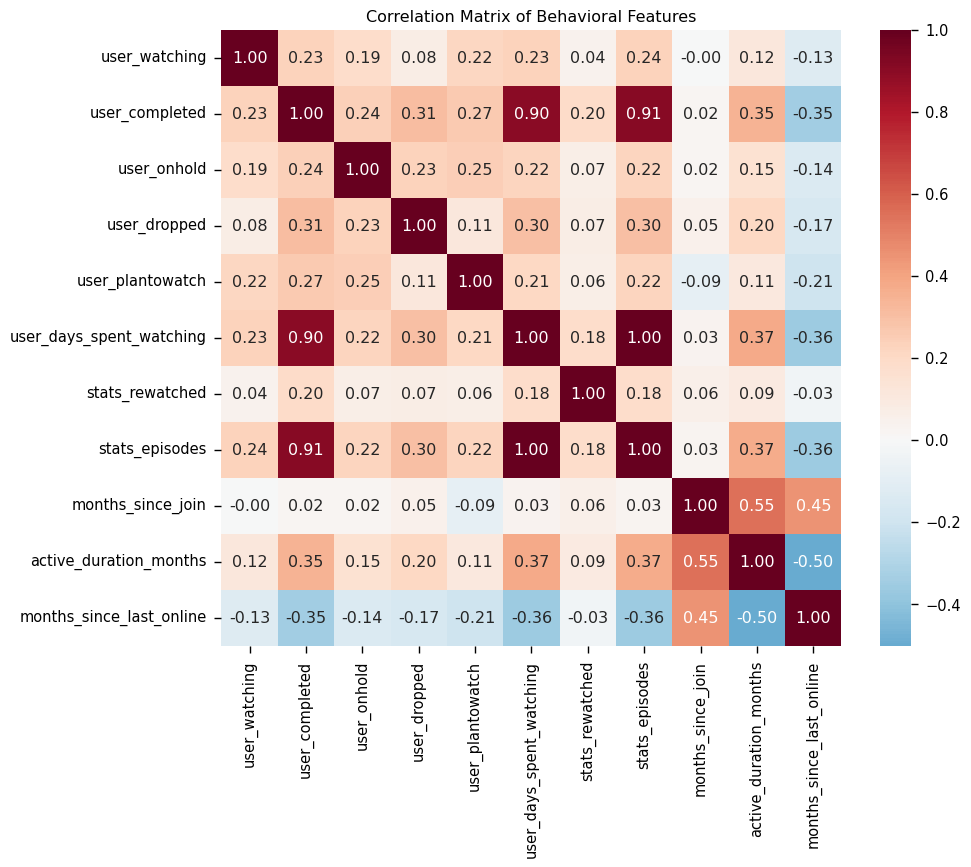

In [ ]:
#@title Correlation Matrix of Behavioral Features
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix for the 11 features
corr_matrix = X_train_beh.corr()

print("--- Correlation Matrix (Numerical) ---")
display(corr_matrix.style.background_gradient(cmap='RdBu_r'))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Correlation Matrix of Behavioral Features')
plt.show()

### 2. Repeated Permutation Importance with Confidence Intervals
Permutation importance is model-agnostic and less prone to the high-cardinality bias of Gini importance. We run it across multiple iterations to establish confidence intervals.

--- Permutation Importance (Numerical) ---


,Feature,Importance_Mean,Importance_Std
3,user_dropped,0.175780,0.001239
0,user_watching,0.050343,0.000890
2,user_onhold,0.040571,0.000874
8,months_since_join,0.038752,0.000372
1,user_completed,0.038366,0.000728
9,active_duration_months,0.037233,0.000653
4,user_plantowatch,0.035969,0.000459
10,months_since_last_online,0.033214,0.000629
5,user_days_spent_watching,0.027877,0.000338
7,stats_episodes,0.025179,0.000671


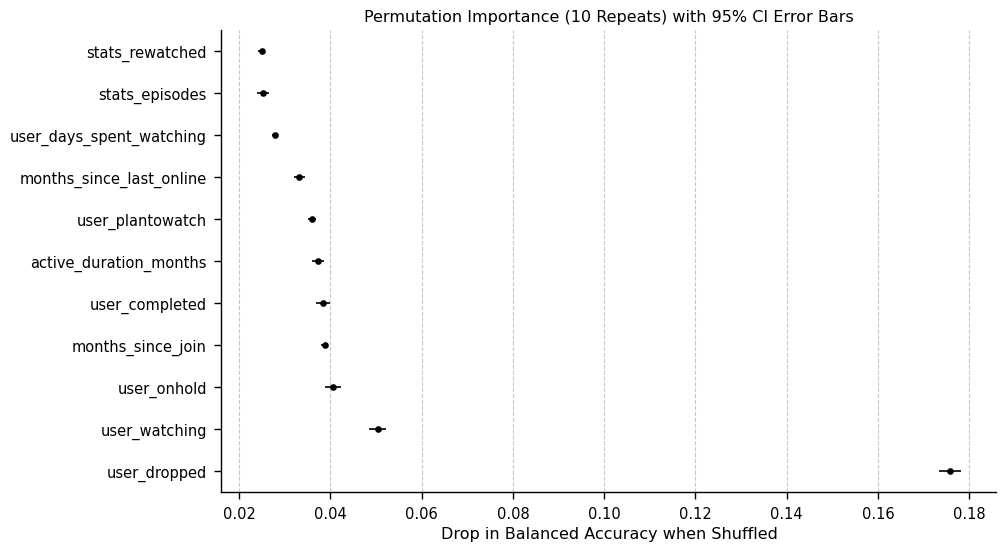

In [ ]:
#@title Repeated Permutation Importance with Confidence Intervals
from sklearn.inspection import permutation_importance
import numpy as np

# Run permutation importance 10 times on a held-out set to get stability metrics
r = permutation_importance(rf_beh, X_train_beh, y_train_beh, n_repeats=10, random_state=42, n_jobs=-1)

# Create a summary dataframe
perm_importance_df = pd.DataFrame({
    'Feature': behavioral_cols,
    'Importance_Mean': r.importances_mean,
    'Importance_Std': r.importances_std
}).sort_values(by='Importance_Mean', ascending=False)

print("--- Permutation Importance (Numerical) ---")
display(perm_importance_df)

# Visualization with Error Bars
plt.figure(figsize=(10, 6))
plt.errorbar(x=perm_importance_df['Importance_Mean'], y=perm_importance_df['Feature'],
             xerr=2*perm_importance_df['Importance_Std'], fmt='o', color='black', capsize=5)
plt.title('Permutation Importance (10 Repeats) with 95% CI Error Bars')
plt.xlabel('Drop in Balanced Accuracy when Shuffled')
plt.grid(axis='x', linestyle='--', alpha=0.7)
sns.despine()
plt.show()

### 3. Targeted Ablation Study
We directly test if `user_dropped` or the 'Activity Group' (completed, watching, episodes, etc.) provides unique information by removing them and observing the change in model performance.

In [ ]:
#@title targeted ablation study: reverse ablation & baseline sync
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

# 1. Define the behavioral core (matches 0.5096 BA baseline)
behavioral_features = [
    'user_watching', 'user_completed', 'user_onhold', 'user_dropped',
    'user_plantowatch', 'user_days_spent_watching', 'stats_rewatched',
    'stats_episodes', 'months_since_join', 'active_duration_months',
    'months_since_last_online'
]

# 2. Define the Activity Volume Group (for grouped ablation)
activity_group = [
    'user_completed', 'user_dropped', 'user_watching',
    'user_plantowatch', 'stats_episodes', 'user_days_spent_watching'
]

# 3. Setup comparison data
# Ensure source dates are datetime objects before feature engineering
users_sync = users_full_f.copy()
for col in ['join_date', 'last_online']:
    users_sync[col] = pd.to_datetime(users_sync[col], errors='coerce')

X_target = engineer_features(users_sync)
# Manually engineer the specific missing time feature required for the baseline sync
X_target['months_since_last_online'] = (TARGET_DATE.year - users_sync['last_online'].dt.year) * 12 + (TARGET_DATE.month - users_sync['last_online'].dt.month)
X_target = X_target.fillna(X_target.median(numeric_only=True))

y_target = LabelEncoder().fit_transform(y_map.loc[users_full_f['username']])

rf_engine = RandomForestClassifier(n_estimators=200, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1)

# 4. Perform Ablation Scenarios
print("Establishing Baseline and Performing Reverse Ablations...")

# Baseline: Full Behavioral Core
scores_base = cross_val_score(rf_engine, X_target[behavioral_features], y_target, cv=kf, scoring='balanced_accuracy')

# Single Feature: Minus user_dropped
feat_minus_dropped = [f for f in behavioral_features if f != 'user_dropped']
scores_no_dropped = cross_val_score(rf_engine, X_target[feat_minus_dropped], y_target, cv=kf, scoring='balanced_accuracy')

# Grouped: Minus Activity Volume Group
feat_no_activity = [f for f in behavioral_features if f not in activity_group]
scores_no_activity = cross_val_score(rf_engine, X_target[feat_no_activity], y_target, cv=kf, scoring='balanced_accuracy')

# 5. Report Results
print(f"\n--- Reverse Ablation Results ---")
print(f"Full Behavioral Baseline:  {np.mean(scores_base):.4f} ± {np.std(scores_base):.4f} (Target: 0.5096)")
print(f"Minus 'user_dropped':      {np.mean(scores_no_dropped):.4f} ± {np.std(scores_no_dropped):.4f}")
print(f"Minus 'Activity Group':    {np.mean(scores_no_activity):.4f} ± {np.std(scores_no_activity):.4f}")

# Calculate Information Contribution
drop_contribution = np.mean(scores_base) - np.mean(scores_no_dropped)
activity_contribution = np.mean(scores_base) - np.mean(scores_no_activity)

print(f"\nContribution Analysis:")
print(f"Unique Signal from 'user_dropped':   {drop_contribution:.4f} BA points")
print(f"Signal from Activity Volume Group:  {activity_contribution:.4f} BA points")

Establishing Baseline and Performing Reverse Ablations...

--- Reverse Ablation Results ---
Full Behavioral Baseline:  0.5091 ± 0.0050 (Target: 0.5096)
Minus 'user_dropped':      0.4438 ± 0.0049
Minus 'Activity Group':    0.4202 ± 0.0053

Contribution Analysis:
Unique Signal from 'user_dropped':   0.0653 BA points
Signal from Activity Volume Group:  0.0889 BA points


## Statistical Tests Used in This Notebook

Throughout this notebook, we employed several statistical tests to validate our findings and compare model performances:

1.  **Corrected Resampled t-test:**
    *   **Purpose:** This test is used to compare the performance of two machine learning models when evaluated using K-Fold Cross-Validation. It accounts for the non-independence of samples across different folds, providing a more robust comparison than a standard paired t-test. It assesses whether there's a statistically significant difference between the average performance of two models.
    *   **Usage:** We used this to compare the Balanced Accuracy and Macro F1 scores of our Decision Tree, Random Forest, and LightGBM models against baselines (Majority and Stratified classifiers), as well as between different strong models.

2.  **Two One-Sided Tests (TOST) for Equivalence:**
    *   **Purpose:** Unlike traditional hypothesis tests that look for a difference, the TOST procedure aims to establish *equivalence* between two treatments or models. It tests whether the difference between two models is practically insignificant, i.e., falls within a pre-defined equivalence margin ($\epsilon$). If the null hypothesis of non-equivalence is rejected, we can conclude that the models are equivalent within that margin.
    *   **Usage:** We applied TOST alongside the corrected resampled t-test to determine if the performance differences between models (e.g., Random Forest vs. LightGBM, Full features vs. Behavioral-Only features) were not only statistically insignificant but also practically equivalent within our defined `EQUIVALENCE_MARGIN` (0.02).

These tests helped us draw meaningful conclusions about the relative strengths of our clustering approaches and classification models, as well as the importance of different feature sets.

#Environment

In [3]:
#@title Cell 1: Hardware & System Info
import platform, psutil, torch, sys

print("Python Version:", sys.version.split()[0])
print("OS:", platform.platform())
print("CPU Count:", psutil.cpu_count(logical=True))
print(f"Total RAM: {psutil.virtual_memory().total / (1024**3):.2f} GB")
!cat /proc/cpuinfo | grep "model name" | head -1
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Execution: Standard CPU Runtime")

Python Version: 3.13.15
OS: Linux-6.6.122+-x86_64-with-glibc2.35
CPU Count: 2
Total RAM: 12.67 GB
model name	: Intel(R) Xeon(R) CPU @ 2.20GHz
Execution: Standard CPU Runtime


In [2]:
#@title Cell 2: Library Versions & Hyperparameter Dumps
import sklearn, xgboost, lightgbm, pandas, numpy

print(f"scikit-learn: {sklearn.__version__}")
print(f"xgboost: {xgboost.__version__}")
print(f"lightgbm: {lightgbm.__version__}")
print(f"pandas: {pandas.__version__}")
print(f"numpy: {numpy.__version__}")

# Check exact fitted estimator parameters (replace variable names if different)
# print("KMeans params:", kmeans.get_params())
# print("RF params:", rf.get_params())
# print("XGBoost params:", xgb.get_params())
# print("LightGBM params:", lgbm.get_params())

scikit-learn: 1.6.1
xgboost: 3.4.1
lightgbm: 4.6.0
pandas: 2.2.3
numpy: 2.1.3
